<div align="center">

# Travel Reimbursement Approval Agent

**A policy-grounded, tool-calling GenAI agent that reviews employee travel claims — and knows when to hand a case to a human.**

Priyanshu Verma &nbsp;·&nbsp; AI Developer Candidate Assignment

![Python](https://img.shields.io/badge/Python-3.10%2B-3776AB?style=flat-square&logo=python&logoColor=white)
![LLM](https://img.shields.io/badge/LLM-Llama%203.3%2070B%20(Groq)-F55036?style=flat-square)
![Providers](https://img.shields.io/badge/Providers-Groq%20%C2%B7%20Ollama%20%C2%B7%20OpenAI-555555?style=flat-square)
![Pattern](https://img.shields.io/badge/Pattern-Tool--calling%20agent%20%2B%20guardrail-2a78d6?style=flat-square)
![Tests](https://img.shields.io/badge/Tests-12%2F12%20passing-0ca30c?style=flat-square)
![Cost](https://img.shields.io/badge/Cost-Free%20tier-4a3aa7?style=flat-square)

</div>

---

### Results at a glance

| Claim | Employee | Decision | Claimed | Approved | Deducted | Deciding factor |
|:--|:--|:--|--:|--:|--:|:--|
| CLM-001 | A. Rivera | ![APPROVE](https://img.shields.io/badge/-APPROVE-0ca30c?style=flat-square) | $1,110.00 | $1,110.00 | $0.00 | Fully compliant, manager tier (POL-APR-02) |
| CLM-002 | B. Osei | ![REJECT](https://img.shields.io/badge/-REJECT-d03b3b?style=flat-square) | $380.00 | $0.00 | $380.00 | Spa + minibar are ineligible (POL-CAT-02) |
| CLM-003 | C. Nakamura | ![PARTIAL APPROVE](https://img.shields.io/badge/-PARTIAL%20APPROVE-eda100?style=flat-square) | $940.00 | $840.00 | $100.00 | Hotel $250/night over the $200 cap (POL-PD-02) |
| CLM-004 | D. Fischer | ![MANUAL REVIEW](https://img.shields.io/badge/-MANUAL%20REVIEW-4a3aa7?style=flat-square) | $3,000.00 | – | – | Business class, missing receipt, > $2,000, nights conflict |
| CLM-005 | E. Haddad | ![MANUAL REVIEW](https://img.shields.io/badge/-MANUAL%20REVIEW-4a3aa7?style=flat-square) | $220.00 | – | – | Missing receipt, group-meal vs per-diem ambiguity |

![Results dashboard](UI%20SS_1.png)

### Why this design is reliable
- **LLM orchestrates, code calculates** — the model plans tool calls and writes the rationale; every dollar comes from deterministic, tested Python.
- **Grounded in policy** — rules are retrieved before deciding and every cited `POL-*` id is verified against the real policy.
- **A guardrail that only moves toward safety** — the LLM can escalate to Manual Review but can never approve what the rules stop.
- **Never breaks the demo** — no API key, a rate limit or a malformed tool call falls back to a deterministic planner that uses the same tools.

### Contents
| # | Section | # | Section |
|:-:|:--|:-:|:--|
| 1 | README · setup · architecture | 7 | Run all claims + audit trail |
| 2 | Policy, limits & sample claims | 8 | Sample outputs |
| 3 | Policy retrieval (grounding) | 9 | Tests & evaluation |
| 4 | Agent tools | 10 | Dashboard & interactive UI |
| 5 | Rule engine & reason codes | 11 | Design Notes & Reasoning |
| 6 | LLM agent loop & guardrail | 12 | Final structured results (JSON) |

## 1 · README

### What it does
A claim comes in as JSON, CSV or through the UI form. An LLM agent decides which policy checks to run, calls deterministic tools, combines their results and proposes a decision. A guardrail re-runs the rules, reconciles the two, and emits a schema-checked result with a full audit trail. The architecture diagram is rendered in section 1.3.

### Setup
1. Python 3.10+ and Jupyter (`pip install notebook` or open in VS Code / Colab).
2. Dependencies are installed by the first code cell (`openai pandas matplotlib scikit-learn ipywidgets`).
3. Pick **one** LLM provider (all free) and set its environment variable **before** starting Jupyter — or paste it in the config cell:

| Variable | Purpose | Default |
|---|---|---|
| `LLM_PROVIDER` | `groq`, `ollama` or `openai` | `groq` |
| `GROQ_API_KEY` | Free key from console.groq.com | – |
| `OPENAI_API_KEY` | Only if `LLM_PROVIDER=openai` | – |
| `LLM_MODEL` | Override model name | `llama-3.3-70b-versatile` (Groq), `qwen2.5:7b` (Ollama), `gpt-4o-mini` (OpenAI) |
| `OLLAMA_BASE_URL` | Local Ollama endpoint | `http://localhost:11434/v1` |

```bash
# Windows (PowerShell)
$env:GROQ_API_KEY="gsk_..."
# macOS / Linux
export GROQ_API_KEY="gsk_..."
# fully local alternative
ollama pull qwen2.5:7b && export LLM_PROVIDER=ollama
```

### How to run
`Kernel → Restart & Run All`. The notebook runs top-to-bottom with no manual steps.
**No key? It still runs** — the agent switches to *offline mode* (a deterministic planner calls the same tools in the same order and writes a templated explanation). The `Mode` column in the results shows which path produced each decision.

### Key design choices (short version — details in *Design Notes & Reasoning*)
* **LLM orchestrates, code calculates.** The LLM chooses tools, reasons about ambiguity and writes the explanation; every dollar figure comes from deterministic Python tools. LLMs are not trusted with arithmetic on money.
* **Grounded in policy.** The agent retrieves POL-* rules before deciding, and every cited `policy_ref` is validated against the real rule ids (hallucinated ids are dropped).
* **Guardrail can only make things safer.** If the LLM is more lenient than the rules, the rules win; if the LLM and rules disagree, the claim goes to `MANUAL_REVIEW`.
* **Fail safe.** LLM errors, malformed tool calls or step-limit overruns fall back to the deterministic path for that claim instead of crashing.

In [1]:
# 1.1 Install dependencies (quiet; safe to re-run)
%pip install -q openai pandas matplotlib scikit-learn ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 1.2 Imports & configuration
import os, re, json, copy, time
from datetime import date
from dataclasses import dataclass, field

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- Optional: paste a key here instead of using an environment variable ---
# os.environ["GROQ_API_KEY"] = "gsk_..."

LLM_PROVIDER = os.getenv("LLM_PROVIDER", "groq").lower()
PROVIDERS = {
    "groq":   {"base_url": "https://api.groq.com/openai/v1", "key_env": "GROQ_API_KEY",  "model": "llama-3.3-70b-versatile"},
    "ollama": {"base_url": os.getenv("OLLAMA_BASE_URL", "http://localhost:11434/v1"), "key_env": None, "model": "qwen2.5:7b"},
    "openai": {"base_url": None, "key_env": "OPENAI_API_KEY", "model": "gpt-4o-mini"},
}
CFG = PROVIDERS.get(LLM_PROVIDER, PROVIDERS["groq"])
LLM_MODEL = os.getenv("LLM_MODEL", CFG["model"])
MAX_AGENT_STEPS = 10          # hard cap on LLM turns per claim
SUBMISSION_WINDOW_DAYS = 30   # POL-TIME-01

def get_llm_client():
    """Return an OpenAI-compatible client, or None (offline mode) if nothing is configured/reachable."""
    try:
        from openai import OpenAI
    except ImportError:
        return None
    if CFG["key_env"]:
        key = os.getenv(CFG["key_env"])
        if not key:
            return None
        return OpenAI(api_key=key, base_url=CFG["base_url"], timeout=60, max_retries=2)
    # Ollama: no key, but check the server is up
    try:
        client = OpenAI(api_key="ollama", base_url=CFG["base_url"], timeout=120, max_retries=0)
        client.models.list()
        return client
    except Exception:
        return None

LLM_CLIENT = get_llm_client()

# ---- Visual design tokens (one place for every colour used in the notebook) ----
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781", "grid": "#e1e0d9",
       "axis": "#c3c2b7", "border": "#d9d7cf", "page": "#f9f9f7", "surface": "#ffffff"}
DECISION_COLORS = {"APPROVE": "#0ca30c", "PARTIAL_APPROVE": "#eda100", "REJECT": "#d03b3b", "MANUAL_REVIEW": "#4a3aa7"}
DECISION_LABELS = {"APPROVE": "Approve", "PARTIAL_APPROVE": "Partial approve", "REJECT": "Reject", "MANUAL_REVIEW": "Manual review"}
AMOUNT_COLORS = {"approved": "#0ca30c", "deducted": "#d03b3b", "pending": "#9085e9"}
BADGE = DECISION_COLORS
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK["axis"], "axes.labelcolor": INK["secondary"], "xtick.color": INK["secondary"],
    "ytick.color": INK["secondary"], "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.titlecolor": INK["primary"], "grid.color": INK["grid"], "grid.linewidth": 0.8,
    "figure.facecolor": INK["surface"], "text.parse_math": False, "axes.facecolor": INK["surface"], "legend.frameon": False})
print(f"Provider: {LLM_PROVIDER} | Model: {LLM_MODEL} | Mode: {'LLM agent' if LLM_CLIENT else 'OFFLINE (deterministic planner)'}")

Provider: groq | Model: llama-3.3-70b-versatile | Mode: OFFLINE (deterministic planner)


### 1.3 Architecture
Rendered from code so the picture always matches the implementation (also saved as `architecture.png`).

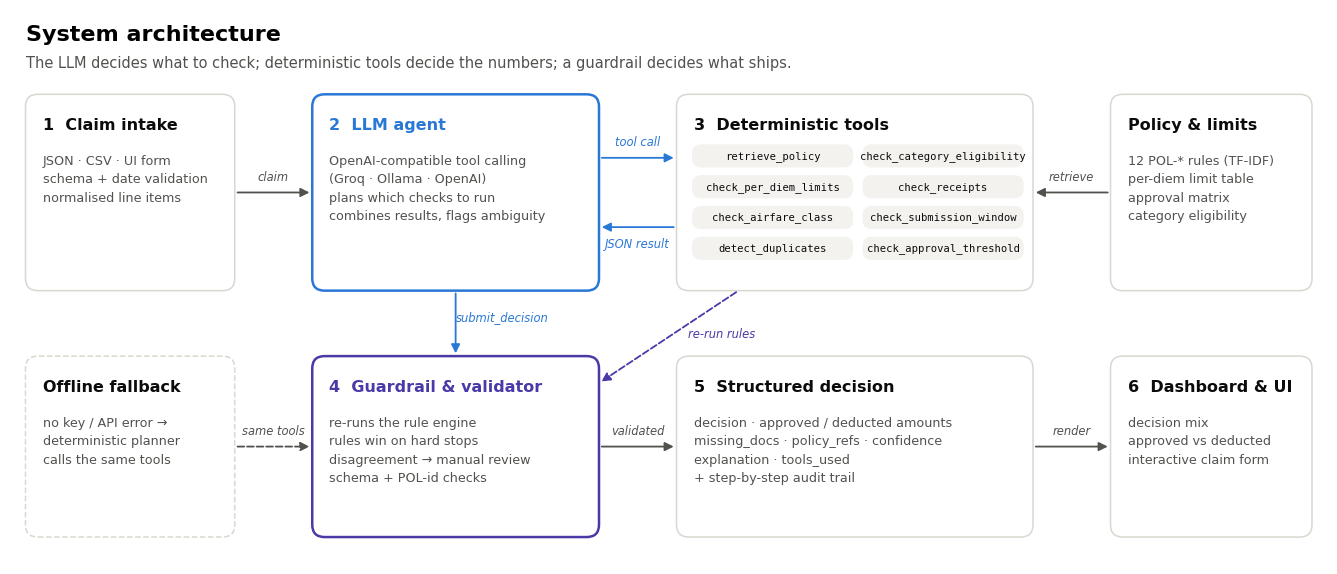

In [3]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def _box(ax, x, y, w, h, title, body="", edge=None, dashed=False, fill="#ffffff"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0,rounding_size=0.16", fc=fill,
                                ec=edge or INK["border"], lw=1.8 if edge else 1.1, ls="--" if dashed else "-"))
    ax.text(x + 0.22, y + h - 0.3, title, fontsize=11.5, weight="bold", va="top", color=edge or INK["primary"])
    if body:
        ax.text(x + 0.22, y + h - 0.78, body, fontsize=9.2, va="top", color=INK["secondary"], linespacing=1.55)

def _arrow(ax, a, b, label=None, dashed=False, color=None, rad=0.0, dy=0.12, ha="center", dx=0.0):
    color = color or INK["secondary"]
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=13, lw=1.3, color=color,
                                 ls="--" if dashed else "-", connectionstyle=f"arc3,rad={rad}", shrinkA=2, shrinkB=2))
    if label:
        ax.text((a[0] + b[0]) / 2 + dx, (a[1] + b[1]) / 2 + dy, label, fontsize=8.3, color=color, ha=ha, va="bottom",
                style="italic")

BLUE, VIOLET = "#2a78d6", DECISION_COLORS["MANUAL_REVIEW"]
fig, ax = plt.subplots(figsize=(17, 7.2))
ax.set_xlim(0, 17); ax.set_ylim(0, 7.2); ax.axis("off")
ax.text(0.2, 7.0, "System architecture", fontsize=16, weight="bold", va="top")
ax.text(0.2, 6.6, "The LLM decides what to check; deterministic tools decide the numbers; a guardrail decides what ships.",
        fontsize=10.5, color=INK["secondary"], va="top")

TOP, BOT, H1, H2 = 3.55, 0.35, 2.55, 2.35
_box(ax, 0.2, TOP, 2.7, H1, "1  Claim intake", "JSON · CSV · UI form\nschema + date validation\nnormalised line items")
_box(ax, 3.9, TOP, 3.7, H1, "2  LLM agent", "OpenAI-compatible tool calling\n(Groq · Ollama · OpenAI)\nplans which checks to run\ncombines results, flags ambiguity", edge=BLUE)
_box(ax, 8.6, TOP, 4.6, H1, "3  Deterministic tools")
tools = ["retrieve_policy", "check_category_eligibility", "check_per_diem_limits", "check_receipts",
         "check_airfare_class", "check_submission_window", "detect_duplicates", "check_approval_threshold"]
for k, t in enumerate(tools):
    cx, cy = 8.8 + (k % 2) * 2.2, TOP + H1 - 0.95 - (k // 2) * 0.4
    ax.add_patch(FancyBboxPatch((cx, cy), 2.08, 0.3, boxstyle="round,pad=0,rounding_size=0.12", fc="#f3f2ee", ec="none"))
    ax.text(cx + 1.04, cy + 0.15, t, fontsize=7.6, ha="center", va="center", family="DejaVu Sans Mono", color=INK["primary"])
_box(ax, 14.2, TOP, 2.6, H1, "Policy & limits", "12 POL-* rules (TF-IDF)\nper-diem limit table\napproval matrix\ncategory eligibility")

_box(ax, 0.2, BOT, 2.7, H2, "Offline fallback", "no key / API error →\ndeterministic planner\ncalls the same tools", dashed=True)
_box(ax, 3.9, BOT, 3.7, H2, "4  Guardrail & validator", "re-runs the rule engine\nrules win on hard stops\ndisagreement → manual review\nschema + POL-id checks", edge=VIOLET)
_box(ax, 8.6, BOT, 4.6, H2, "5  Structured decision", "decision · approved / deducted amounts\nmissing_docs · policy_refs · confidence\nexplanation · tools_used\n+ step-by-step audit trail")
_box(ax, 14.2, BOT, 2.6, H2, "6  Dashboard & UI", "decision mix\napproved vs deducted\ninteractive claim form")

ym = TOP + H1 / 2
_arrow(ax, (2.9, ym), (3.9, ym), "claim")
_arrow(ax, (7.6, ym + 0.45), (8.6, ym + 0.45), "tool call", color=BLUE)
_arrow(ax, (8.6, ym - 0.45), (7.6, ym - 0.45), "JSON result", color=BLUE, dy=-0.3)
_arrow(ax, (14.2, ym), (13.2, ym), "retrieve")
_arrow(ax, (5.75, TOP), (5.75, BOT + H2), "submit_decision", color=BLUE, dy=0, ha="left")
_arrow(ax, (9.4, TOP), (7.6, BOT + H2 - 0.35), "re-run rules", dashed=True, color=VIOLET, dy=-0.05, dx=0.25, ha="left")
yb = BOT + H2 / 2
_arrow(ax, (2.9, yb), (3.9, yb), "same tools", dashed=True)
_arrow(ax, (7.6, yb), (8.6, yb), "validated")
_arrow(ax, (13.2, yb), (14.2, yb), "render")
fig.savefig("architecture.png", dpi=130, bbox_inches="tight")
plt.show()

## 2 · Inputs: policy, limit table, approval matrix, sample claims
Appendix A is encoded as data with its stable `POL-*` ids so the agent can retrieve and cite them. The limit table, approval matrix and category-eligibility file are small dictionaries derived from the same policy (single source of truth).

In [4]:
# 2.1 Policy (Appendix A) — every rule keeps its stable id
POLICY = [
    {"id": "POL-CAT-01", "section": "Eligible & Ineligible Categories", "title": "Eligible categories",
     "text": "Reimbursable when incurred for a documented business purpose: airfare (economy class only, see POL-AIR-01), "
             "lodging (hotel room charges), meals (subject to per-diem limits, see POL-PD-01), ground transport (taxi, rideshare, "
             "train, rental car, parking), conference / registration fees."},
    {"id": "POL-CAT-02", "section": "Eligible & Ineligible Categories", "title": "Ineligible items",
     "text": "Never reimbursable; rejected (deducted in full): alcohol and minibar charges; spa, gym and personal entertainment; "
             "in-room movies, personal shopping, gifts; traffic fines, penalties and late fees; any personal (non-business) expense."},
    {"id": "POL-PD-01", "section": "Per-Diem & Category Limits", "title": "Meals per-diem",
     "text": "Meals: maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed."},
    {"id": "POL-PD-02", "section": "Per-Diem & Category Limits", "title": "Lodging nightly cap",
     "text": "Lodging: maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed."},
    {"id": "POL-PD-03", "section": "Per-Diem & Category Limits", "title": "Ground transport daily cap",
     "text": "Ground transport: maximum $50 per day. Amounts above the cap are deducted."},
    {"id": "POL-AIR-01", "section": "Per-Diem & Category Limits", "title": "Airfare class",
     "text": "Only economy class airfare is reimbursable. Business/first-class fares are a policy exception and must be routed "
             "to Manual Review (not auto-deducted, because a pre-approval may exist)."},
    {"id": "POL-RCT-01", "section": "Receipt Rules", "title": "Receipt required above $25",
     "text": "Any single line item greater than $25 requires an attached, itemized receipt. Airfare and lodging always require "
             "a receipt regardless of amount."},
    {"id": "POL-RCT-02", "section": "Receipt Rules", "title": "Missing receipt handling",
     "text": "If a receipt is missing for an item that requires one, the item is not silently rejected; the claim is routed to "
             "Manual Review so the reviewer can request the receipt."},
    {"id": "POL-APR-01", "section": "Approval Thresholds", "title": "Auto-approve tier",
     "text": "Total reimbursable amount (after per-diem deductions) <= $500: may be auto-approved by the agent if fully compliant."},
    {"id": "POL-APR-02", "section": "Approval Thresholds", "title": "Manager tier",
     "text": "Total > $500 and <= $2,000: eligible for approval, treated as approvable when fully compliant."},
    {"id": "POL-APR-03", "section": "Approval Thresholds", "title": "Director / Manual-Review tier",
     "text": "Total > $2,000: exceeds the agent's auto-approval authority and must be routed to Manual Review "
             "(director approval required), even if otherwise compliant."},
    {"id": "POL-TIME-01", "section": "Timeliness", "title": "Submission window",
     "text": "Claims must be submitted within 30 days of the expense date. Late claims are routed to Manual Review."},
]
POLICY_BY_ID = {p["id"]: p for p in POLICY}
VALID_POLICY_IDS = set(POLICY_BY_ID)

DECISION_GUIDANCE = """Approve: every item eligible, all receipts present, all within per-diem, total within an approvable tier (POL-APR-01/02).
Partially Approve: claim is valid but some amounts exceed per-diem caps (or include ineligible items next to valid ones); reimburse up to the cap and deduct the excess.
Reject: the claimed items are ineligible (POL-CAT-02) with nothing reimbursable.
Manual Review: any ambiguity, policy exception, high value (POL-APR-03), missing required receipt (POL-RCT-02) or conflicting information. Prefer Manual Review over forcing a decision."""

# 2.2 Limit table (POL-PD-*)
LIMITS = {
    "meals":            {"cap": 75.0,  "unit": "day",   "policy": "POL-PD-01"},
    "lodging":          {"cap": 200.0, "unit": "night", "policy": "POL-PD-02"},
    "ground_transport": {"cap": 50.0,  "unit": "day",   "policy": "POL-PD-03"},
}

# 2.3 Approval matrix (POL-APR-*) — evaluated on reimbursable total after per-diem deductions
APPROVAL_MATRIX = [
    {"tier": "AUTO_APPROVE", "min_exclusive": None,   "max_inclusive": 500.0,  "approvable": True,  "policy": "POL-APR-01"},
    {"tier": "MANAGER",      "min_exclusive": 500.0,  "max_inclusive": 2000.0, "approvable": True,  "policy": "POL-APR-02"},
    {"tier": "DIRECTOR",     "min_exclusive": 2000.0, "max_inclusive": None,   "approvable": False, "policy": "POL-APR-03"},
]

# 2.4 Category eligibility file (POL-CAT-*)
ELIGIBLE_CATEGORIES = {"airfare", "lodging", "meals", "ground_transport", "conference_fees"}
INELIGIBLE_CATEGORIES = {"alcohol", "minibar", "spa", "gym", "entertainment", "in_room_movies", "movies",
                         "personal_shopping", "shopping", "gifts", "fines", "penalties", "late_fees", "personal"}
INELIGIBLE_KEYWORDS = ["alcohol", "wine", "beer", "bar tab", "minibar", "spa", "gym", "massage", "movie",
                       "entertainment", "shopping", "gift", "fine", "penalty", "late fee", "personal"]
RECEIPT_THRESHOLD = 25.0
ALWAYS_RECEIPT = {"airfare", "lodging"}

In [5]:
# 2.5 Sample claims (Appendix B) — claim intake from JSON (the same loader also accepts a CSV of line items)
CLAIMS_JSON = """
[
 {"claim_id": "CLM-001", "employee": "A. Rivera", "purpose": "Attend 2-day industry conference (business)",
  "trip_start": "2026-06-10", "trip_end": "2026-06-12", "submitted": "2026-06-20",
  "items": [
   {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": true},
   {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": true},
   {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": true},
   {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": true}],
  "total_claimed": 1110.00},
 {"claim_id": "CLM-002", "employee": "B. Osei", "purpose": "Weekend hotel stay",
  "trip_start": "2026-06-14", "trip_end": "2026-06-15", "submitted": "2026-06-25",
  "items": [
   {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": true},
   {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": true}],
  "total_claimed": 380.00},
 {"claim_id": "CLM-003", "employee": "C. Nakamura", "purpose": "Client site visit (business)",
  "trip_start": "2026-06-08", "trip_end": "2026-06-10", "submitted": "2026-06-22",
  "items": [
   {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": true},
   {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": true},
   {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": true}],
  "total_claimed": 940.00},
 {"claim_id": "CLM-004", "employee": "D. Fischer", "purpose": "International vendor negotiation (business)",
  "trip_start": "2026-06-16", "trip_end": "2026-06-18", "submitted": "2026-06-28",
  "items": [
   {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": true},
   {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": false}],
  "total_claimed": 3000.00},
 {"claim_id": "CLM-005", "employee": "E. Haddad", "purpose": "Client dinner / business development",
  "trip_start": "2026-06-11", "trip_end": "2026-06-11", "submitted": "2026-06-24",
  "items": [
   {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": false}],
  "total_claimed": 220.00}
]
"""

REQUIRED_CLAIM_FIELDS = {"claim_id", "employee", "purpose", "trip_start", "trip_end", "submitted", "items"}

def normalize_claim(raw: dict) -> dict:
    """Validate + normalise one claim. Raises ValueError with a readable message on bad input."""
    missing = REQUIRED_CLAIM_FIELDS - set(raw)
    if missing:
        raise ValueError(f"Claim is missing fields: {sorted(missing)}")
    c = copy.deepcopy(raw)
    for k in ("trip_start", "trip_end", "submitted"):
        date.fromisoformat(c[k])  # raises on bad dates
    if not c["items"]:
        raise ValueError("Claim has no line items")
    for i, it in enumerate(c["items"], start=1):
        it["line_id"] = it.get("line_id") or f"L{i}"
        it["category"] = str(it["category"]).strip().lower().replace(" ", "_").replace("-", "_")
        it["amount"] = round(float(it["amount"]), 2)
        if it["amount"] < 0:
            raise ValueError(f"{c['claim_id']} {it['line_id']}: negative amount")
        rec = it.get("receipt_attached")
        it["receipt_attached"] = rec if isinstance(rec, bool) else str(rec).strip().lower() in {"yes", "y", "true", "1"}
    c["computed_total"] = round(sum(it["amount"] for it in c["items"]), 2)
    c.setdefault("total_claimed", c["computed_total"])
    return c

def load_claims_from_json(text: str) -> list:
    data = json.loads(text)
    return [normalize_claim(c) for c in (data if isinstance(data, list) else [data])]

def load_claims_from_csv(path: str) -> list:
    """CSV intake: one row per line item with claim_id, employee, purpose, trip_start, trip_end, submitted,
    category, description, amount, receipt_attached."""
    df = pd.read_csv(path)
    claims = []
    for cid, g in df.groupby("claim_id", sort=False):
        head = g.iloc[0]
        claims.append(normalize_claim({
            "claim_id": cid, "employee": head["employee"], "purpose": head["purpose"],
            "trip_start": head["trip_start"], "trip_end": head["trip_end"], "submitted": head["submitted"],
            "items": g[["category", "description", "amount", "receipt_attached"]].to_dict("records")}))
    return claims

CLAIMS = load_claims_from_json(CLAIMS_JSON)
CLAIM_STORE = {c["claim_id"]: c for c in CLAIMS}   # tools look claims up by id

pd.DataFrame([{**{k: c[k] for k in ("claim_id", "employee", "purpose", "trip_start", "trip_end", "submitted")},
               "line_items": len(c["items"]), "total_claimed": c["total_claimed"]} for c in CLAIMS])

,claim_id,employee,purpose,trip_start,trip_end,submitted,line_items,total_claimed
0,CLM-001,A. Rivera,Attend 2-day industry conference (business),2026-06-10,2026-06-12,2026-06-20,4,1110.0
1,CLM-002,B. Osei,Weekend hotel stay,2026-06-14,2026-06-15,2026-06-25,2,380.0
2,CLM-003,C. Nakamura,Client site visit (business),2026-06-08,2026-06-10,2026-06-22,3,940.0
3,CLM-004,D. Fischer,International vendor negotiation (business),2026-06-16,2026-06-18,2026-06-28,2,3000.0
4,CLM-005,E. Haddad,Client dinner / business development,2026-06-11,2026-06-11,2026-06-24,1,220.0


## 3 · Context grounding — policy retrieval
A lightweight retriever (TF-IDF + cosine similarity) over the POL-* rules. With 12 short rules a vector DB would be over-engineering; TF-IDF is free, deterministic, offline and good enough. The agent calls it as the `retrieve_policy` tool before deciding, and the retrieved snippets are kept in the audit trail.

In [6]:
class PolicyRetriever:
    def __init__(self, rules):
        self.rules = rules
        self.docs = [f"{r['id']} {r['section']} {r['title']}. {r['text']}" for r in rules]
        self.vec = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
        self.matrix = self.vec.fit_transform(self.docs)

    def search(self, query: str, k: int = 3):
        # exact id lookup first (e.g. "POL-AIR-01")
        ids = [i.upper() for i in re.findall(r"POL-[A-Za-z]+-\d+", query)]
        hits = [dict(POLICY_BY_ID[i], score=1.0) for i in ids if i in POLICY_BY_ID]
        sims = cosine_similarity(self.vec.transform([query]), self.matrix)[0]
        for idx in sims.argsort()[::-1]:
            if len(hits) >= k:
                break
            r = self.rules[idx]
            if sims[idx] > 0 and r["id"] not in {h["id"] for h in hits}:
                hits.append(dict(r, score=round(float(sims[idx]), 3)))
        return hits

RETRIEVER = PolicyRetriever(POLICY)
for q in ["business class flight", "hotel minibar and spa", "receipt missing for dinner"]:
    print(f"{q!r:32} -> {[ (h['id'], h['score']) for h in RETRIEVER.search(q)]}")

'business class flight'          -> [('POL-AIR-01', 0.386), ('POL-CAT-01', 0.102), ('POL-CAT-02', 0.047)]
'hotel minibar and spa'          -> [('POL-CAT-02', 0.145), ('POL-CAT-01', 0.069)]
'receipt missing for dinner'     -> [('POL-RCT-02', 0.519), ('POL-RCT-01', 0.256)]


## 4 · Tools the agent can call
Each tool is a plain Python function that works on a `claim_id`, returns JSON-serialisable results and the `policy_refs` it relied on. The same functions are exposed to the LLM through OpenAI-style function schemas.

| Tool | What it checks | Policy |
|---|---|---|
| `retrieve_policy` | Fetches relevant rule text | all |
| `check_category_eligibility` | Eligible vs ineligible categories (also scans descriptions, e.g. "minibar" inside a hotel bill) | POL-CAT-01/02 |
| `check_per_diem_limits` | Meals/lodging/ground caps, units from description vs trip dates, data conflicts, per-person ambiguity | POL-PD-01/02/03 |
| `check_receipts` | Receipt required above $25; airfare & lodging always | POL-RCT-01/02 |
| `check_airfare_class` | Economy only; business/first = exception | POL-AIR-01 |
| `check_submission_window` | Submitted within 30 days of the expense date | POL-TIME-01 |
| `detect_duplicates` | Same line twice, or same employee/amount/category in another claim | — |
| `check_approval_threshold` | Tier on the reimbursable total after deductions | POL-APR-01/02/03 |

In [7]:
def _claim(claim_id):
    if claim_id not in CLAIM_STORE:
        raise KeyError(f"Unknown claim_id {claim_id!r}")
    return CLAIM_STORE[claim_id]

def _trip_days(c):
    return (date.fromisoformat(c["trip_end"]) - date.fromisoformat(c["trip_start"])).days + 1

def tool_retrieve_policy(query: str, k: int = 3):
    hits = RETRIEVER.search(query, k=k)
    return {"query": query, "results": [{"id": h["id"], "title": h["title"], "text": h["text"], "score": h["score"]} for h in hits],
            "policy_refs": [h["id"] for h in hits]}

def tool_check_category_eligibility(claim_id: str):
    c = _claim(claim_id)
    lines, refs = [], set()
    for it in c["items"]:
        cat, desc = it["category"], it["description"].lower()
        kw = next((k for k in INELIGIBLE_KEYWORDS if re.search(rf"\b{re.escape(k)}s?\b", desc)), None)
        if cat in INELIGIBLE_CATEGORIES:
            status, why = "ineligible", f"category '{cat}' is never reimbursable"
            refs.add("POL-CAT-02")
        elif cat in ELIGIBLE_CATEGORIES and kw:
            status, why = "needs_review", f"eligible category but description mentions '{kw}' (possible ineligible charge)"
            refs.update({"POL-CAT-01", "POL-CAT-02"})
        elif cat in ELIGIBLE_CATEGORIES:
            status, why = "eligible", f"'{cat}' is an eligible business category"
            refs.add("POL-CAT-01")
        else:
            status, why = "unknown", f"category '{cat}' is not in the policy category list"
            refs.update({"POL-CAT-01", "POL-CAT-02"})
        lines.append({"line_id": it["line_id"], "category": cat, "amount": it["amount"], "status": status, "reason": why})
    inel = round(sum(l["amount"] for l in lines if l["status"] == "ineligible"), 2)
    return {"claim_id": claim_id, "lines": lines, "ineligible_total": inel,
            "all_ineligible": all(l["status"] == "ineligible" for l in lines),
            "needs_review": [l["line_id"] for l in lines if l["status"] in ("needs_review", "unknown")],
            "policy_refs": sorted(refs)}

def tool_check_per_diem_limits(claim_id: str):
    c = _claim(claim_id)
    days = _trip_days(c)
    supported = {"day": days, "night": max(days - 1, 0)}
    lines, conflicts, ambiguities, refs = [], [], [], set()
    for it in c["items"]:
        cat = it["category"]
        if cat not in LIMITS:
            continue
        lim = LIMITS[cat]; unit = lim["unit"]; refs.add(lim["policy"])
        m = re.search(rf"(\d+)\s*{unit}s?\b", it["description"].lower())
        described = int(m.group(1)) if m else None
        units, source = (described, "description") if described else (supported[unit], "trip dates")
        if described and described > supported[unit]:
            conflicts.append(f"{it['line_id']} {cat}: description says {described} {unit}(s) but trip "
                             f"{c['trip_start']}..{c['trip_end']} supports only {supported[unit]}")
            units, source = supported[unit], "trip dates (conflict)"
        if units == 0:
            conflicts.append(f"{it['line_id']} {cat}: no {unit}s supported by trip dates")
        people = re.search(r"\bfor\s+(\d+)\b", it["description"].lower())
        if cat == "meals" and people and int(people.group(1)) > 1:
            ambiguities.append(f"{it['line_id']} meals: group meal for {people.group(1)} people — unclear whether "
                               f"the per-person daily cap or a client-entertainment pre-approval applies")
        cap = round(lim["cap"] * units, 2)
        excess = round(max(it["amount"] - cap, 0.0), 2)
        lines.append({"line_id": it["line_id"], "category": cat, "amount": it["amount"], "units": units,
                      "unit": unit, "units_source": source, "cap_per_unit": lim["cap"], "cap_total": cap,
                      "excess": excess, "policy": lim["policy"]})
    return {"claim_id": claim_id, "trip_days": days, "trip_nights": supported["night"], "lines": lines,
            "total_excess": round(sum(l["excess"] for l in lines), 2),
            "conflicts": conflicts, "ambiguities": ambiguities, "policy_refs": sorted(refs)}

def tool_check_receipts(claim_id: str):
    c = _claim(claim_id)
    missing = []
    for it in c["items"]:
        required = it["amount"] > RECEIPT_THRESHOLD or it["category"] in ALWAYS_RECEIPT
        if required and not it["receipt_attached"]:
            why = "always required for " + it["category"] if it["category"] in ALWAYS_RECEIPT else f"amount > ${RECEIPT_THRESHOLD:.0f}"
            missing.append({"line_id": it["line_id"], "category": it["category"], "amount": it["amount"],
                            "doc": f"Itemized receipt for {it['category']} – {it['description']} (${it['amount']:.2f})",
                            "reason": why})
    return {"claim_id": claim_id, "all_present": not missing, "missing": missing,
            "policy_refs": ["POL-RCT-01", "POL-RCT-02"] if missing else ["POL-RCT-01"]}

def tool_check_airfare_class(claim_id: str):
    c = _claim(claim_id)
    lines = []
    for it in c["items"]:
        if it["category"] != "airfare":
            continue
        d = it["description"].lower()
        if re.search(r"business|first|premium", d):
            cls, status = re.search(r"business|first|premium", d).group(0), "exception"
        elif "economy" in d or "coach" in d:
            cls, status = "economy", "compliant"
        else:
            cls, status = "unspecified", "ambiguous"
        lines.append({"line_id": it["line_id"], "amount": it["amount"], "fare_class": cls, "status": status})
    return {"claim_id": claim_id, "airfare_lines": lines,
            "exception": any(l["status"] == "exception" for l in lines),
            "ambiguous": any(l["status"] == "ambiguous" for l in lines),
            "policy_refs": ["POL-AIR-01"] if lines else []}

def tool_check_submission_window(claim_id: str):
    c = _claim(claim_id)
    # Conservative: measure from the first expense date (trip start)
    lag = (date.fromisoformat(c["submitted"]) - date.fromisoformat(c["trip_start"])).days
    issue = None
    if lag < 0:
        issue = "submitted before the trip started (date conflict)"
    return {"claim_id": claim_id, "days_since_first_expense": lag, "within_window": 0 <= lag <= SUBMISSION_WINDOW_DAYS,
            "window_days": SUBMISSION_WINDOW_DAYS, "issue": issue, "policy_refs": ["POL-TIME-01"]}

def tool_detect_duplicates(claim_id: str):
    c = _claim(claim_id)
    dups, seen = [], {}
    for it in c["items"]:
        key = (it["category"], it["amount"], it["description"].lower())
        if key in seen:
            dups.append(f"{it['line_id']} duplicates {seen[key]} within the claim")
        seen[key] = it["line_id"]
    for other in CLAIM_STORE.values():
        if other["claim_id"] == claim_id or other["employee"] != c["employee"]:
            continue
        overlap = not (other["trip_end"] < c["trip_start"] or other["trip_start"] > c["trip_end"])
        for it in c["items"]:
            for ot in other["items"]:
                if overlap and it["category"] == ot["category"] and it["amount"] == ot["amount"]:
                    dups.append(f"{it['line_id']} matches {other['claim_id']} {ot['line_id']} (same employee, overlapping dates)")
    return {"claim_id": claim_id, "duplicates_found": bool(dups), "details": dups, "policy_refs": []}

def tool_check_approval_threshold(claim_id: str):
    """Tier is computed on the reimbursable total = claimed - ineligible items - per-diem excess."""
    c = _claim(claim_id)
    elig = tool_check_category_eligibility(claim_id)
    pd_ = tool_check_per_diem_limits(claim_id)
    reimbursable = round(c["computed_total"] - elig["ineligible_total"] - pd_["total_excess"], 2)
    for t in APPROVAL_MATRIX:
        lo_ok = t["min_exclusive"] is None or reimbursable > t["min_exclusive"]
        hi_ok = t["max_inclusive"] is None or reimbursable <= t["max_inclusive"]
        if lo_ok and hi_ok:
            return {"claim_id": claim_id, "reimbursable_total": reimbursable, "tier": t["tier"],
                    "within_agent_authority": t["approvable"], "policy_refs": [t["policy"]]}

TOOL_FUNCS = {
    "retrieve_policy": tool_retrieve_policy,
    "check_category_eligibility": tool_check_category_eligibility,
    "check_per_diem_limits": tool_check_per_diem_limits,
    "check_receipts": tool_check_receipts,
    "check_airfare_class": tool_check_airfare_class,
    "check_submission_window": tool_check_submission_window,
    "detect_duplicates": tool_detect_duplicates,
    "check_approval_threshold": tool_check_approval_threshold,
}

# quick smoke test of every tool on one claim
print(json.dumps(tool_check_per_diem_limits("CLM-003"), indent=1)[:600])

{
 "claim_id": "CLM-003",
 "trip_days": 3,
 "trip_nights": 2,
 "lines": [
  {
   "line_id": "L2",
   "category": "lodging",
   "amount": 500.0,
   "units": 2,
   "unit": "night",
   "units_source": "description",
   "cap_per_unit": 200.0,
   "cap_total": 400.0,
   "excess": 100.0,
   "policy": "POL-PD-02"
  },
  {
   "line_id": "L3",
   "category": "meals",
   "amount": 140.0,
   "units": 2,
   "unit": "day",
   "units_source": "description",
   "cap_per_unit": 75.0,
   "cap_total": 150.0,
   "excess": 0.0,
   "policy": "POL-PD-01"
  }
 ],
 "total_excess": 100.0,
 "conflicts": [],
 "ambiguitie


In [8]:
# 4.1 Tool schemas exposed to the LLM (OpenAI function-calling format)
def _claim_tool(name, desc):
    return {"type": "function", "function": {"name": name, "description": desc, "parameters": {
        "type": "object", "properties": {"claim_id": {"type": "string"}}, "required": ["claim_id"]}}}

TOOL_SCHEMAS = [
    {"type": "function", "function": {"name": "retrieve_policy",
        "description": "Search the travel policy and return the most relevant POL-* rules with their text. Call before deciding.",
        "parameters": {"type": "object", "properties": {
            "query": {"type": "string", "description": "What you need policy context for, e.g. 'business class airfare'"},
            "k": {"type": "integer", "description": "Number of rules (1-5)", "default": 3}}, "required": ["query"]}}},
    _claim_tool("check_category_eligibility", "Classify each line item as eligible / ineligible / needs_review per POL-CAT-01/02."),
    _claim_tool("check_per_diem_limits", "Apply meals/lodging/ground-transport caps (POL-PD-*). Returns caps, excess to deduct, data conflicts and ambiguities."),
    _claim_tool("check_receipts", "List line items missing a required receipt (POL-RCT-01/02)."),
    _claim_tool("check_airfare_class", "Check airfare lines are economy class (POL-AIR-01). Only useful when the claim has airfare."),
    _claim_tool("check_submission_window", "Check the claim was submitted within 30 days of the first expense (POL-TIME-01)."),
    _claim_tool("detect_duplicates", "Detect duplicate line items within the claim or across other claims by the same employee."),
    _claim_tool("check_approval_threshold", "Compute the reimbursable total after deductions and return its approval tier (POL-APR-*)."),
    {"type": "function", "function": {"name": "submit_decision",
        "description": "Submit your final recommendation. Call exactly once, after the required checks.",
        "parameters": {"type": "object", "properties": {
            "decision": {"type": "string", "enum": ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]},
            "policy_refs": {"type": "array", "items": {"type": "string"}, "description": "POL-* ids that drove the decision"},
            "review_reasons": {"type": "array", "items": {"type": "string"}, "description": "Why a human must look (empty if none)"},
            "explanation": {"type": "string", "description": "2-4 sentences a claims reviewer can read. Quote amounts from tool results only."},
            "confidence": {"type": "number", "description": "0-1, your confidence the decision is right"}},
            "required": ["decision", "policy_refs", "explanation", "confidence"]}}},
]
REQUIRED_TOOLS = {"check_category_eligibility", "check_per_diem_limits", "check_receipts", "check_approval_threshold"}
print(f"{len(TOOL_SCHEMAS)} tools exposed to the LLM:", [t["function"]["name"] for t in TOOL_SCHEMAS])

9 tools exposed to the LLM: ['retrieve_policy', 'check_category_eligibility', 'check_per_diem_limits', 'check_receipts', 'check_airfare_class', 'check_submission_window', 'detect_duplicates', 'check_approval_threshold', 'submit_decision']


## 5 · Deterministic rule engine (ground truth for amounts + guardrail + fallback)
This encodes the *Decision Guidance* section of the policy. It is used in two ways:
1. **Guardrail** — after the LLM submits a decision, `validate_decision` re-runs these rules and reconciles.
2. **Fallback** — if no LLM is configured or the LLM fails, this produces the decision directly.

Amount convention used in the output:
* `APPROVE` / `PARTIAL_APPROVE` / `REJECT` → `approved_amount` = reimbursable total, `deducted_amount` = ineligible items + per-diem excess.
* Every decision also carries **reason codes** (e.g. `MISSING_RECEIPT`, `PREMIUM_AIRFARE`, `OVER_AGENT_AUTHORITY`) so a reviewer queue can be filtered and routed.
* `MANUAL_REVIEW` → `approved_amount = 0` (nothing is paid until a human decides). `deducted_amount` only includes items that are *never* reimbursable (POL-CAT-02); cap-based deductions are shown as *provisional* in the explanation because the reviewer may override them (pre-approval, corrected receipt, etc.).

In [9]:
def rule_baseline(claim_id: str, results: dict = None) -> dict:
    """Combine tool results into a policy decision. `results` lets the agent pass already-computed tool outputs."""
    r = {k: v for k, v in (results or {}).items() if "error" not in v}   # ignore failed tool calls
    for name in ["check_category_eligibility", "check_per_diem_limits", "check_receipts", "check_airfare_class",
                 "check_submission_window", "detect_duplicates", "check_approval_threshold"]:
        if name not in r:
            r[name] = TOOL_FUNCS[name](claim_id)
    elig, pdl, rct, air, tim, dup, thr = (r[n] for n in ["check_category_eligibility", "check_per_diem_limits",
        "check_receipts", "check_airfare_class", "check_submission_window", "detect_duplicates", "check_approval_threshold"])

    reasons = []

    if elig["needs_review"]:
        reasons.append(f"Category needs review for line(s) {', '.join(elig['needs_review'])} (POL-CAT-01/02)")
    if air["exception"]:
        reasons.append("Business/first-class airfare is a policy exception; a pre-approval may exist (POL-AIR-01)")
    if air["ambiguous"]:
        reasons.append("Airfare class not stated (POL-AIR-01)")
    if rct["missing"]:
        reasons.append("Missing required receipt(s): " + "; ".join(m["doc"] for m in rct["missing"]) + " (POL-RCT-01/02)")
    if not tim["within_window"]:
        reasons.append(f"Submitted {tim['days_since_first_expense']} days after first expense; window is 30 days (POL-TIME-01)")
    if tim["issue"]:
        reasons.append(f"Date conflict: {tim['issue']}")
    for cf in pdl["conflicts"]:
        reasons.append(f"Conflicting information: {cf}")
    for am in pdl["ambiguities"]:
        reasons.append(f"Ambiguity: {am} (POL-PD-01)")
    if dup["duplicates_found"]:
        reasons.append("Possible duplicate: " + "; ".join(dup["details"]))
    if not elig["all_ineligible"] and not thr["within_agent_authority"]:
        reasons.append(f"Reimbursable total ${thr['reimbursable_total']:,.2f} exceeds the $2,000 agent authority; "
                       f"director approval required (POL-APR-03)")

    claim = _claim(claim_id)
    inel = elig["ineligible_total"]
    excess = pdl["total_excess"]
    reimbursable = thr["reimbursable_total"]

    if elig["all_ineligible"] and not reasons:
        decision, approved, deducted = "REJECT", 0.0, claim["computed_total"]
    elif reasons:
        decision, approved, deducted = "MANUAL_REVIEW", 0.0, inel
    elif inel > 0 or excess > 0:
        decision, approved, deducted = "PARTIAL_APPROVE", reimbursable, round(inel + excess, 2)
    else:
        decision, approved, deducted = "APPROVE", reimbursable, 0.0

    # policy_refs = the rules that actually drove this decision (not everything that was retrieved)
    refs = set()
    if decision == "REJECT":
        refs.add("POL-CAT-02")
    else:
        refs.update(elig["policy_refs"])
        refs.update(l["policy"] for l in pdl["lines"] if l["excess"] > 0)
        refs.update(thr["policy_refs"])
        if decision in ("APPROVE", "PARTIAL_APPROVE"):
            refs.update({"POL-RCT-01"} | {l["policy"] for l in pdl["lines"]})
        if decision == "MANUAL_REVIEW":
            refs.update(re.findall(r"POL-[A-Z]+-\d+", " ".join(reasons)))
            if rct["missing"]: refs.update(rct["policy_refs"])
            if air["exception"] or air["ambiguous"]: refs.add("POL-AIR-01")
            if not tim["within_window"]: refs.add("POL-TIME-01")
            for cf in pdl["conflicts"]:
                cat = cf.split()[1].rstrip(":")
                if cat in LIMITS: refs.add(LIMITS[cat]["policy"])
            if pdl["ambiguities"]: refs.add("POL-PD-01")

    # Reason codes (machine-readable) + short findings (human-readable, used by cards and the UI)
    codes, findings = [], []          # findings: (kind, text) with kind in ok / bad / flag
    n_items = len(claim["items"])
    inel_lines = [l for l in elig["lines"] if l["status"] == "ineligible"]
    if inel_lines:
        codes.append("INELIGIBLE_ITEMS")
        findings += [("bad", f"{l['category'].replace('_', ' ').capitalize()} ${l['amount']:,.0f} is ineligible") for l in inel_lines]
    elif not elig["needs_review"]:
        codes.append("ALL_ELIGIBLE"); findings.append(("ok", f"All {n_items} items eligible" if n_items > 1 else "Item is eligible"))
    if elig["needs_review"]:
        codes.append("CATEGORY_UNCLEAR"); findings.append(("flag", "Category unclear: " + ", ".join(elig["needs_review"])))
    if air["exception"]:
        codes.append("PREMIUM_AIRFARE")
        findings.append(("flag", f"Business-class airfare ${sum(l['amount'] for l in air['airfare_lines'] if l['status'] == 'exception'):,.0f}"))
    if air["ambiguous"]:
        codes.append("AIRFARE_CLASS_UNKNOWN"); findings.append(("flag", "Airfare class not stated"))
    if rct["missing"]:
        codes.append("MISSING_RECEIPT")
        findings += [("flag", f"No receipt: {m['category'].replace('_', ' ')} ${m['amount']:,.0f}") for m in rct["missing"]]
    elif not inel_lines:
        codes.append("RECEIPTS_COMPLETE"); findings.append(("ok", "Receipts complete"))
    over = [l for l in pdl["lines"] if l["excess"] > 0]
    if over and not reasons:
        codes.append("CAP_EXCEEDED")
        findings += [("bad", f"{l['category'].capitalize()} ${l['amount']:,.0f} > cap ${l['cap_total']:,.0f} (−${l['excess']:,.0f})") for l in over]
    elif pdl["lines"] and not over and not inel_lines:
        codes.append("WITHIN_CAPS"); findings.append(("ok", "Within per-diem caps"))
    if pdl["conflicts"]:
        codes.append("DATA_CONFLICT")
        for l in pdl["lines"]:
            if "conflict" in l["units_source"]:
                m = re.search(r"(\d+)\s*" + l["unit"], next(it["description"] for it in claim["items"] if it["line_id"] == l["line_id"]).lower())
                findings.append(("flag", f"{m.group(1) if m else '?'} {l['unit']}s claimed, dates allow {l['units']}"))
    if pdl["ambiguities"]:
        codes.append("GROUP_MEAL_AMBIGUITY"); findings.append(("flag", "Group meal vs $75/day per-person cap"))
    if not tim["within_window"]:
        codes.append("LATE_SUBMISSION" if tim["days_since_first_expense"] > 0 else "DATE_CONFLICT")
        findings.append(("flag", f"Submitted {tim['days_since_first_expense']} days after first expense"))
    if dup["duplicates_found"]:
        codes.append("POSSIBLE_DUPLICATE"); findings.append(("flag", "Possible duplicate claim"))
    if not elig["all_ineligible"]:
        if thr["within_agent_authority"]:
            codes.append(f"TIER_{thr['tier']}")
            if not reasons:
                findings.append(("ok", f"${reimbursable:,.0f} → {thr['tier'].replace('_', '-').lower()} tier"))
        else:
            codes.append("OVER_AGENT_AUTHORITY"); findings.append(("flag", f"${reimbursable:,.0f} > $2,000 agent authority"))

    missing_docs = [m["doc"] for m in rct["missing"]]
    if air["exception"]:
        missing_docs.append("Pre-approval for business/first-class airfare (POL-AIR-01)")
    if not thr["within_agent_authority"] and decision == "MANUAL_REVIEW":
        missing_docs.append("Director approval (total > $2,000, POL-APR-03)")

    return {"claim_id": claim_id, "decision": decision, "approved_amount": round(approved, 2),
            "deducted_amount": round(deducted, 2), "provisional_reimbursable": reimbursable,
            "provisional_deduction": round(inel + excess, 2), "missing_docs": missing_docs,
            "review_reasons": reasons, "reason_codes": codes, "findings": findings,
            "policy_refs": sorted(refs), "tool_results": r}

pd.DataFrame([{"claim_id": b["claim_id"], "rule_decision": b["decision"], "approved": b["approved_amount"],
               "deducted": b["deducted_amount"], "reason_codes": ", ".join(b["reason_codes"])}
              for b in (rule_baseline(c["claim_id"]) for c in CLAIMS)]).style.hide(axis="index").format(
    {"approved": "${:,.2f}", "deducted": "${:,.2f}"})

claim_id,rule_decision,approved,deducted,reason_codes
CLM-001,APPROVE,"$1,110.00",$0.00,"ALL_ELIGIBLE, RECEIPTS_COMPLETE, WITHIN_CAPS, TIER_MANAGER"
CLM-002,REJECT,$0.00,$380.00,INELIGIBLE_ITEMS
CLM-003,PARTIAL_APPROVE,$840.00,$100.00,"ALL_ELIGIBLE, RECEIPTS_COMPLETE, CAP_EXCEEDED, TIER_MANAGER"
CLM-004,MANUAL_REVIEW,$0.00,$0.00,"ALL_ELIGIBLE, PREMIUM_AIRFARE, MISSING_RECEIPT, DATA_CONFLICT, OVER_AGENT_AUTHORITY"
CLM-005,MANUAL_REVIEW,$0.00,$0.00,"ALL_ELIGIBLE, MISSING_RECEIPT, GROUP_MEAL_AMBIGUITY, TIER_AUTO_APPROVE"


## 6 · The agent — LLM tool calling + workflow control + guardrails
**Loop:** the LLM receives the claim and the decision guidance, chooses which tools to call (it can call several per turn), reads the JSON results, and finally calls `submit_decision`.

**Workflow control enforced in code (not just in the prompt):**
* `submit_decision` is refused until the 4 required checks have run → the LLM is told which ones are missing and continues.
* Unknown tool names / bad arguments return an error message to the LLM instead of crashing.
* Max `MAX_AGENT_STEPS` turns; then fall back.

**Guardrail (`validate_decision`):**
| LLM vs rules | Outcome |
|---|---|
| Agree | Accept, confidence high |
| Rules say MANUAL_REVIEW, LLM says otherwise | MANUAL_REVIEW (hard stops cannot be overridden) |
| LLM says MANUAL_REVIEW, rules don't | Accept the escalation (being cautious is allowed) |
| Both auto-decide but differ | MANUAL_REVIEW — conflicting signals |

Amounts always come from tools; `policy_refs` are filtered to real ids; the output is schema-checked.

In [10]:
SYSTEM_PROMPT = f"""You are a Travel Reimbursement Approval Agent for a company's finance team.
Your job: evaluate ONE claim against the travel policy and submit a structured recommendation.

How to work:
1. Use tools to gather facts. Always run: check_category_eligibility, check_per_diem_limits, check_receipts, check_approval_threshold.
   Use retrieve_policy to ground yourself in the exact rule text, and call check_airfare_class (if there is airfare),
   check_submission_window and detect_duplicates when relevant. You may call several tools in one turn.
2. Never do money arithmetic yourself; use the amounts the tools return.
3. If anything is missing, conflicting, ambiguous or a policy exception, choose MANUAL_REVIEW and list the reasons.
   Prefer MANUAL_REVIEW over forcing a decision.
4. Finish by calling submit_decision exactly once. Cite only real POL-* ids.

Decision guidance:
{DECISION_GUIDANCE}
"""

@dataclass
class AgentRun:
    claim_id: str
    mode: str = "llm"
    audit: list = field(default_factory=list)
    tool_results: dict = field(default_factory=dict)
    tools_used: list = field(default_factory=list)
    proposal: dict = None
    error: str = None

    def log(self, kind, name, detail):
        self.audit.append({"step": len(self.audit) + 1, "kind": kind, "name": name, "detail": detail})

def execute_tool(run: AgentRun, name: str, args: dict):
    if name not in TOOL_FUNCS:
        return {"error": f"Unknown tool {name}. Available: {list(TOOL_FUNCS)}"}
    try:
        if name == "retrieve_policy":
            res = TOOL_FUNCS[name](query=str(args.get("query", "")), k=int(args.get("k", 3) or 3))
        else:
            res = TOOL_FUNCS[name](run.claim_id)   # claim_id pinned: the LLM cannot evaluate a different claim
    except Exception as e:
        res = {"error": f"{type(e).__name__}: {e}"}
    run.tool_results[name] = res
    if name not in run.tools_used:
        run.tools_used.append(name)
    run.log("tool_call", name, {"args": args, "result": res})
    return res

def run_llm_agent(claim: dict, client) -> AgentRun:
    run = AgentRun(claim["claim_id"], mode="llm")
    claim_view = {k: v for k, v in claim.items() if k != "computed_total"}
    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": "Evaluate this claim:\n" + json.dumps(claim_view, indent=1)}]
    for step in range(MAX_AGENT_STEPS):
        resp = client.chat.completions.create(model=LLM_MODEL, messages=messages, tools=TOOL_SCHEMAS,
                                              tool_choice="auto", temperature=0)
        msg = resp.choices[0].message
        assistant_msg = {"role": "assistant", "content": msg.content or ""}
        if msg.tool_calls:
            assistant_msg["tool_calls"] = [{"id": tc.id, "type": "function",
                                            "function": {"name": tc.function.name, "arguments": tc.function.arguments or "{}"}}
                                           for tc in msg.tool_calls]
        messages.append(assistant_msg)
        if msg.content:
            run.log("llm_thought", "assistant", msg.content[:500])
        if not msg.tool_calls:
            messages.append({"role": "user", "content": "Continue. Use the tools, then call submit_decision."})
            continue
        for tc in msg.tool_calls:
            try:
                args = json.loads(tc.function.arguments or "{}")
            except json.JSONDecodeError:
                args, out = {}, {"error": "Arguments were not valid JSON. Retry with valid JSON."}
                messages.append({"role": "tool", "tool_call_id": tc.id, "content": json.dumps(out)})
                continue
            if tc.function.name == "submit_decision":
                missing = REQUIRED_TOOLS - set(run.tool_results)
                if missing:   # workflow control: refuse premature decisions
                    out = {"error": f"Decision refused: run these checks first: {sorted(missing)}"}
                    run.log("guardrail", "premature_submit", out["error"])
                else:
                    run.proposal = args
                    run.log("llm_decision", "submit_decision", args)
                    out = {"status": "received"}
            else:
                out = execute_tool(run, tc.function.name, args)
            messages.append({"role": "tool", "tool_call_id": tc.id, "content": json.dumps(out, default=str)})
        if run.proposal:
            return run
    raise RuntimeError(f"No decision after {MAX_AGENT_STEPS} steps")

def run_offline_planner(claim: dict, reason: str = "no LLM configured") -> AgentRun:
    """Deterministic stand-in for the LLM: same tools, fixed plan, templated rationale."""
    run = AgentRun(claim["claim_id"], mode="offline")
    run.log("planner", "offline_mode", reason)
    cats = {it["category"] for it in claim["items"]}
    execute_tool(run, "retrieve_policy", {"query": " ".join(sorted(cats)) + " receipts per diem approval"})
    plan = ["check_category_eligibility", "check_per_diem_limits", "check_receipts"]
    if "airfare" in cats:
        plan.append("check_airfare_class")
    plan += ["check_submission_window", "detect_duplicates", "check_approval_threshold"]
    for name in plan:
        execute_tool(run, name, {"claim_id": claim["claim_id"]})
    return run

In [11]:
def template_explanation(base: dict) -> str:
    d, c = base["decision"], _claim(base["claim_id"])
    r = base["tool_results"]
    if d == "APPROVE":
        return (f"All {len(c['items'])} items are eligible, receipts are attached and every amount is within per-diem limits. "
                f"Reimbursable total ${base['approved_amount']:,.2f} falls in the {r['check_approval_threshold']['tier'].lower()} tier, "
                f"so the claim is approvable.")
    if d == "PARTIAL_APPROVE":
        parts = [f"{l['category']} ${l['amount']:,.2f} vs cap ${l['cap_total']:,.2f} ({l['units']} {l['unit']}s x ${l['cap_per_unit']:.0f}) -> ${l['excess']:,.2f} deducted"
                 for l in r["check_per_diem_limits"]["lines"] if l["excess"] > 0]
        inel = r["check_category_eligibility"]["ineligible_total"]
        if inel:
            parts.append(f"ineligible items ${inel:,.2f} deducted")
        return (f"Claim is valid but exceeds policy caps: {'; '.join(parts)}. "
                f"Reimburse ${base['approved_amount']:,.2f} and deduct ${base['deducted_amount']:,.2f}.")
    if d == "REJECT":
        cats = ", ".join(l["category"] for l in r["check_category_eligibility"]["lines"])
        return (f"Every line item ({cats}) is an ineligible personal expense under POL-CAT-02, so nothing is reimbursable; "
                f"the full ${base['deducted_amount']:,.2f} is deducted.")
    return ("Routed to manual review: " + " | ".join(base["review_reasons"]) +
            f". Provisionally reimbursable if cleared: ${base['provisional_reimbursable']:,.2f}"
            + (f" (provisional deduction ${base['provisional_deduction']:,.2f})." if base["provisional_deduction"] else "."))

DECISIONS = {"APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"}
OUTPUT_FIELDS = ["claim_id", "decision", "approved_amount", "deducted_amount", "missing_docs",
                 "policy_refs", "confidence", "explanation", "tools_used"]

def validate_decision(run: AgentRun) -> dict:
    """Output validator + guardrail. Reconciles the LLM proposal with deterministic rules."""
    base = rule_baseline(run.claim_id, run.tool_results)
    p = run.proposal or {}
    llm_dec = str(p.get("decision", "")).upper().strip()
    notes = []

    if run.mode != "llm" or llm_dec not in DECISIONS:
        final = base["decision"]
        if run.mode == "llm":
            notes.append(f"LLM decision '{llm_dec}' invalid; used rule decision")
        agree = None
    elif llm_dec == base["decision"]:
        final, agree = llm_dec, True
    elif base["decision"] == "MANUAL_REVIEW":
        final, agree = "MANUAL_REVIEW", False
        notes.append(f"LLM proposed {llm_dec} but hard policy checks require MANUAL_REVIEW")
    elif llm_dec == "MANUAL_REVIEW":
        final, agree = "MANUAL_REVIEW", False
        notes.append("LLM escalated to MANUAL_REVIEW: " + "; ".join(p.get("review_reasons") or ["ambiguity flagged"]))
    else:
        final, agree = "MANUAL_REVIEW", False
        notes.append(f"LLM ({llm_dec}) and rules ({base['decision']}) disagree -> conflicting signals")

    # Amounts always from deterministic tools
    if final == base["decision"]:
        approved, deducted = base["approved_amount"], base["deducted_amount"]
    else:  # escalated to manual review
        approved, deducted = 0.0, base["tool_results"]["check_category_eligibility"]["ineligible_total"]

    # policy refs: union of rule refs and LLM refs, filtered to real ids
    llm_refs = [str(x).upper() for x in (p.get("policy_refs") or [])]
    bad = [x for x in llm_refs if x not in VALID_POLICY_IDS]
    if bad:
        notes.append(f"Dropped unknown policy ids from LLM: {bad}")
    refs = sorted(set(base["policy_refs"]) | {x for x in llm_refs if x in VALID_POLICY_IDS})

    # explanation
    expl = str(p.get("explanation") or "").strip() if run.mode == "llm" else ""
    if not expl or final != llm_dec:
        expl = template_explanation({**base, "decision": final, "approved_amount": approved, "deducted_amount": deducted,
                                     "review_reasons": base["review_reasons"] + notes})
    # confidence: agreement + data quality
    flags = len(base["tool_results"]["check_per_diem_limits"]["conflicts"]) + len(base["tool_results"]["check_per_diem_limits"]["ambiguities"])
    conf = {True: 0.95, False: 0.65, None: 0.88}[agree] - 0.05 * flags
    if run.mode == "llm" and isinstance(p.get("confidence"), (int, float)):
        conf = min(conf, max(float(p["confidence"]), 0.5))
    conf = round(min(max(conf, 0.5), 0.99), 2)

    result = {"claim_id": run.claim_id, "decision": final, "approved_amount": float(approved),
              "deducted_amount": float(deducted), "missing_docs": base["missing_docs"], "policy_refs": refs,
              "confidence": conf, "explanation": expl, "tools_used": run.tools_used + ["validate_decision"]}
    # schema check
    assert list(result) == OUTPUT_FIELDS and result["decision"] in DECISIONS
    assert result["approved_amount"] + result["deducted_amount"] <= _claim(run.claim_id)["computed_total"] + 0.01
    run.log("guardrail", "validate_decision", {"rule_decision": base["decision"], "llm_decision": llm_dec or None,
                                              "final": final, "notes": notes, "review_reasons": base["review_reasons"]})
    return result

def evaluate_claim(claim: dict, client=None, verbose=False):
    """Public entry point: intake -> agent -> guardrail -> structured result (+ audit trail)."""
    claim = normalize_claim(claim)
    CLAIM_STORE[claim["claim_id"]] = claim
    client = LLM_CLIENT if client is None else client
    if client:
        try:
            run = run_llm_agent(claim, client)
        except Exception as e:   # API error, rate limit, malformed tool call, step limit...
            run = run_offline_planner(claim, reason=f"LLM failed ({type(e).__name__}: {str(e)[:150]}) -> fallback")
            run.mode = "fallback"
    else:
        run = run_offline_planner(claim)
    result = validate_decision(run)
    if verbose:
        print(f"{claim['claim_id']} [{run.mode}] -> {result['decision']}")
    return result, run

## 7 · Evaluate all five claims

In [12]:
RESULTS, RUNS = [], {}
for c in CLAIMS:
    res, run = evaluate_claim(c)
    RESULTS.append(res)
    RUNS[c["claim_id"]] = run
    print(f"  {c['claim_id']}  {run.mode:<8} {len(run.tools_used):>2} tools  →  {res['decision']}")
    if LLM_CLIENT:
        time.sleep(1)   # be gentle with free-tier rate limits

results_df = pd.DataFrame(RESULTS)
results_df.insert(2, "mode", [RUNS[r["claim_id"]].mode for r in RESULTS])
results_df.insert(3, "total_claimed", [CLAIM_STORE[r["claim_id"]]["computed_total"] for r in RESULTS])

def style_results(df):
    view = df[["claim_id", "decision", "mode", "total_claimed", "approved_amount", "deducted_amount", "confidence"]].copy()
    view["reason_codes"] = [", ".join(rule_baseline(c)["reason_codes"]) for c in view["claim_id"]]
    view.columns = ["Claim", "Decision", "Engine", "Claimed", "Approved", "Deducted", "Confidence", "Reason codes"]
    return (view.style.hide(axis="index")
            .format({"Claimed": "${:,.2f}", "Approved": "${:,.2f}", "Deducted": "${:,.2f}", "Confidence": "{:.0%}"})
            .map(lambda d: f"background-color:{DECISION_COLORS.get(d, '')};color:white;font-weight:600" if d in DECISION_COLORS else "",
                 subset=["Decision"])
            .set_table_styles([{"selector": "th", "props": "background:#1f1f1e;color:white;text-align:left;padding:6px 10px"},
                               {"selector": "td", "props": "padding:6px 10px;border-bottom:1px solid #e1e0d9"}]))
style_results(results_df)

  CLM-001  offline   8 tools  →  APPROVE
  CLM-002  offline   7 tools  →  REJECT
  CLM-003  offline   8 tools  →  PARTIAL_APPROVE
  CLM-004  offline   8 tools  →  MANUAL_REVIEW
  CLM-005  offline   7 tools  →  MANUAL_REVIEW


Claim,Decision,Engine,Claimed,Approved,Deducted,Confidence,Reason codes
CLM-001,APPROVE,offline,"$1,110.00","$1,110.00",$0.00,88%,"ALL_ELIGIBLE, RECEIPTS_COMPLETE, WITHIN_CAPS, TIER_MANAGER"
CLM-002,REJECT,offline,$380.00,$0.00,$380.00,88%,INELIGIBLE_ITEMS
CLM-003,PARTIAL_APPROVE,offline,$940.00,$840.00,$100.00,88%,"ALL_ELIGIBLE, RECEIPTS_COMPLETE, CAP_EXCEEDED, TIER_MANAGER"
CLM-004,MANUAL_REVIEW,offline,"$3,000.00",$0.00,$0.00,83%,"ALL_ELIGIBLE, PREMIUM_AIRFARE, MISSING_RECEIPT, DATA_CONFLICT, OVER_AGENT_AUTHORITY"
CLM-005,MANUAL_REVIEW,offline,$220.00,$0.00,$0.00,83%,"ALL_ELIGIBLE, MISSING_RECEIPT, GROUP_MEAL_AMBIGUITY, TIER_AUTO_APPROVE"


In [13]:
# 7.1 Audit trail — what the agent did, step by step, in plain language
def summarize_step(a):
    d = a["detail"]
    if a["kind"] != "tool_call":
        if a["name"] == "validate_decision":
            notes = "; ".join(d["notes"]) or "no override needed"
            return f"rules → {d['rule_decision']} · LLM → {d['llm_decision'] or 'n/a'} · final → {d['final']} ({notes})"
        return d if isinstance(d, str) else json.dumps(d, default=str)[:200]
    r, n = d["result"], a["name"]
    if "error" in r:
        return "error: " + r["error"]
    if n == "retrieve_policy":
        return "retrieved " + ", ".join(r["policy_refs"])
    if n == "check_category_eligibility":
        ok = sum(l["status"] == "eligible" for l in r["lines"])
        return f"{ok}/{len(r['lines'])} items eligible" + (f" · ineligible ${r['ineligible_total']:,.2f}" if r["ineligible_total"] else "")
    if n == "check_per_diem_limits":
        parts = [f"{l['category']} ${l['amount']:,.0f} vs cap ${l['cap_total']:,.0f}" + (f" → −${l['excess']:,.0f}" if l["excess"] else " ✓")
                 for l in r["lines"]] or ["no capped categories"]
        return "; ".join(parts) + (f" · {len(r['conflicts'])} conflict(s)" if r["conflicts"] else "") + \
               (f" · {len(r['ambiguities'])} ambiguity" if r["ambiguities"] else "")
    if n == "check_receipts":
        return "all required receipts attached ✓" if r["all_present"] else "missing: " + "; ".join(f"{m['category']} ${m['amount']:,.0f}" for m in r["missing"])
    if n == "check_airfare_class":
        return "; ".join(f"{l['fare_class']} → {l['status']}" for l in r["airfare_lines"])
    if n == "check_submission_window":
        return f"{r['days_since_first_expense']} days after first expense (limit {r['window_days']}) " + ("✓" if r["within_window"] else "✗")
    if n == "detect_duplicates":
        return "no duplicates ✓" if not r["duplicates_found"] else "; ".join(r["details"])
    if n == "check_approval_threshold":
        return f"reimbursable ${r['reimbursable_total']:,.2f} → {r['tier']} tier" + ("" if r["within_agent_authority"] else " (exceeds agent authority)")
    return json.dumps(r, default=str)[:200]

STAGE = {"tool_call": "Tool", "guardrail": "Guardrail", "llm_decision": "LLM decision", "llm_thought": "LLM", "planner": "Planner"}

def show_audit(claim_id):
    rows = [{"#": a["step"], "Stage": STAGE.get(a["kind"], a["kind"]), "Action": a["name"], "Outcome": summarize_step(a)}
            for a in RUNS[claim_id].audit]
    return (pd.DataFrame(rows).style.hide(axis="index")
            .set_caption(f"Audit trail — {claim_id} ({RUNS[claim_id].mode} mode)")
            .set_table_styles([{"selector": "caption", "props": "caption-side:top;font-weight:700;font-size:14px;text-align:left;padding:4px 0"},
                               {"selector": "th", "props": "background:#1f1f1e;color:white;text-align:left;padding:6px 10px"},
                               {"selector": "td", "props": "text-align:left;padding:5px 10px;border-bottom:1px solid #e1e0d9"}]))

show_audit("CLM-004")

#,Stage,Action,Outcome
1,Planner,offline_mode,no LLM configured
2,Tool,retrieve_policy,"retrieved POL-RCT-01, POL-AIR-01, POL-PD-02"
3,Tool,check_category_eligibility,2/2 items eligible
4,Tool,check_per_diem_limits,lodging $600 vs cap $400 → −$200 · 1 conflict(s)
5,Tool,check_receipts,missing: lodging $600
6,Tool,check_airfare_class,business → exception
7,Tool,check_submission_window,12 days after first expense (limit 30) ✓
8,Tool,detect_duplicates,no duplicates ✓
9,Tool,check_approval_threshold,"reimbursable $2,800.00 → DIRECTOR tier (exceeds agent authority)"
10,Guardrail,validate_decision,rules → MANUAL_REVIEW · LLM → n/a · final → MANUAL_REVIEW (no override needed)


## 8 · Sample outputs — decisions with explanations
Three representative outcomes (one of each kind) followed by the remaining two.

In [14]:
MARK = {"ok": ("✓", "#0ca30c"), "bad": ("✗", "#d03b3b"), "flag": ("!", "#4a3aa7")}

def result_card(r):
    c, col = CLAIM_STORE[r["claim_id"]], DECISION_COLORS[r["decision"]]
    base = rule_baseline(r["claim_id"])
    finds = "".join(f'<div style="margin:2px 0"><b style="color:{MARK[k][1]};display:inline-block;width:16px">{MARK[k][0]}</b>{t}</div>'
                    for k, t in base["findings"])
    stat = lambda label, v, color="#0b0b0b": (f'<div style="flex:1"><div style="font-size:11px;color:#898781;text-transform:uppercase;'
                                               f'letter-spacing:.05em">{label}</div><div style="font-size:19px;font-weight:700;color:{color}">{v}</div></div>')
    docs = "".join(f"<li>{d}</li>" for d in r["missing_docs"])
    return f"""
<div style="font-family:system-ui,-apple-system,'Segoe UI',sans-serif;border:1px solid #e1e0d9;border-top:4px solid {col};
            border-radius:10px;padding:14px 18px;margin:10px 0;background:#fff;color:#0b0b0b;box-shadow:0 1px 3px rgba(0,0,0,.06)">
  <div style="display:flex;justify-content:space-between;align-items:center">
    <div><span style="font-size:16px;font-weight:700">{r['claim_id']}</span>
         <span style="color:#52514e"> · {c['employee']} · {c['purpose']}</span></div>
    <span style="background:{col};color:#fff;padding:3px 12px;border-radius:999px;font-size:12px;font-weight:600">{DECISION_LABELS[r['decision']]}</span>
  </div>
  <div style="display:flex;gap:12px;margin:12px 0 8px">
    {stat("Claimed", f"${c['computed_total']:,.2f}")}{stat("Pending review", f"${c['computed_total'] - r['approved_amount'] - r['deducted_amount']:,.2f}", "#4a3aa7") if r["decision"] == "MANUAL_REVIEW" else stat("Approved", f"${r['approved_amount']:,.2f}", "#006300")}
    {stat("Deducted", f"${r['deducted_amount']:,.2f}", "#b42f2f")}{stat("Confidence", f"{r['confidence']:.0%}")}
  </div>
  <div style="display:flex;gap:24px;border-top:1px solid #eeede8;padding-top:10px">
    <div style="flex:1;font-size:13px">{finds}</div>
    <div style="flex:1.6;font-size:13px;color:#2b2b2a;line-height:1.5">{r['explanation']}</div>
  </div>
  {f'<div style="margin-top:8px;font-size:12.5px"><b>Documents to request</b><ul style="margin:4px 0 0 18px;padding:0">{docs}</ul></div>' if docs else ''}
  <div style="margin-top:10px;font-size:11.5px;color:#898781">
    <b>Policy</b> {' · '.join(r['policy_refs'])} &nbsp;&nbsp; <b>Tools</b> {' → '.join(r['tools_used'])}</div>
</div>"""

order = ["CLM-003", "CLM-002", "CLM-004", "CLM-001", "CLM-005"]
by_id = {r["claim_id"]: r for r in RESULTS}
display(HTML("".join(result_card(by_id[i]) for i in order)))

## 9 · Tests & evaluation
Expected outcomes were worked out by hand from Appendix A before building the agent. The tests also cover edge cases that are not in the sample set (late submission, ineligible item inside an otherwise valid claim, missing airfare receipt, date conflict, LLM disagreement).

In [15]:
EXPECTED = {
    "CLM-001": ("APPROVE",          1110.00,   0.00),  # all compliant, $1,110 manager tier
    "CLM-002": ("REJECT",              0.00, 380.00),  # spa + minibar, POL-CAT-02
    "CLM-003": ("PARTIAL_APPROVE",   840.00, 100.00),  # lodging $250/night vs $200 cap
    "CLM-004": ("MANUAL_REVIEW",       0.00,   0.00),  # business class + missing hotel receipt + > $2,000 + 3 nights vs 2-night trip
    "CLM-005": ("MANUAL_REVIEW",       0.00,   0.00),  # missing receipt for $220 meal + group-meal ambiguity
}
passed = 0
for r in RESULTS:
    exp = EXPECTED[r["claim_id"]]
    got = (r["decision"], r["approved_amount"], r["deducted_amount"])
    ok = got == exp
    passed += ok
    print(f"{'PASS' if ok else 'FAIL'} {r['claim_id']}: expected {exp}, got {got}")

# Edge cases (deterministic path, so they are stable)
def variant(base_id, new_id, **changes):
    c = copy.deepcopy(CLAIM_STORE[base_id]); c["claim_id"] = new_id
    c["employee"] = "Test User " + new_id   # different employee so the duplicate detector stays quiet
    items_patch = changes.pop("items_patch", None)
    c.update(changes)
    if items_patch:
        items_patch(c["items"])
    return c

edge_cases = [
    (variant("CLM-001", "T-LATE", submitted="2026-08-01"), "MANUAL_REVIEW", "late submission (POL-TIME-01)"),
    (variant("CLM-001", "T-MIXED", items_patch=lambda it: it.append(
        {"category": "alcohol", "description": "Hotel bar", "amount": 45.0, "receipt_attached": True})), "PARTIAL_APPROVE", "ineligible item deducted"),
    (variant("CLM-003", "T-NORCPT", items_patch=lambda it: it[0].update(receipt_attached=False)), "MANUAL_REVIEW", "airfare receipt missing"),
    (variant("CLM-001", "T-DATES", submitted="2026-06-01"), "MANUAL_REVIEW", "submitted before trip"),
    (variant("CLM-002", "T-SMALL", items_patch=lambda it: it.pop(0)), "REJECT", "single minibar charge"),
    (variant("CLM-003", "T-DUP", employee="C. Nakamura"), "MANUAL_REVIEW", "resubmitted duplicate of CLM-003"),
]
for claim, exp, label in edge_cases:
    res, _ = evaluate_claim(claim, client=False)   # client=False -> deterministic planner
    ok = res["decision"] == exp
    passed += ok
    print(f"{'PASS' if ok else 'FAIL'} {label:30} -> {res['decision']} (approved {res['approved_amount']}, deducted {res['deducted_amount']})")
    CLAIM_STORE.pop(claim["claim_id"], None)

# Guardrail test: a lenient (wrong) LLM proposal must not override a hard stop
fake = run_offline_planner(CLAIM_STORE["CLM-004"]); fake.mode = "llm"
fake.proposal = {"decision": "APPROVE", "policy_refs": ["POL-FAKE-99"], "explanation": "Looks fine", "confidence": 0.99}
g = validate_decision(fake)
ok = g["decision"] == "MANUAL_REVIEW" and "POL-FAKE-99" not in g["policy_refs"] and g["confidence"] < 0.9
passed += ok
print(f"{'PASS' if ok else 'FAIL'} guardrail blocks lenient LLM + drops fake policy id -> {g['decision']}, conf {g['confidence']}")

total = len(RESULTS) + len(edge_cases) + 1
print(f"\n{passed}/{total} tests passed")

PASS CLM-001: expected ('APPROVE', 1110.0, 0.0), got ('APPROVE', 1110.0, 0.0)
PASS CLM-002: expected ('REJECT', 0.0, 380.0), got ('REJECT', 0.0, 380.0)
PASS CLM-003: expected ('PARTIAL_APPROVE', 840.0, 100.0), got ('PARTIAL_APPROVE', 840.0, 100.0)
PASS CLM-004: expected ('MANUAL_REVIEW', 0.0, 0.0), got ('MANUAL_REVIEW', 0.0, 0.0)
PASS CLM-005: expected ('MANUAL_REVIEW', 0.0, 0.0), got ('MANUAL_REVIEW', 0.0, 0.0)
PASS late submission (POL-TIME-01)  -> MANUAL_REVIEW (approved 0.0, deducted 0.0)
PASS ineligible item deducted       -> PARTIAL_APPROVE (approved 1110.0, deducted 45.0)
PASS airfare receipt missing        -> MANUAL_REVIEW (approved 0.0, deducted 0.0)
PASS submitted before trip          -> MANUAL_REVIEW (approved 0.0, deducted 0.0)
PASS single minibar charge          -> REJECT (approved 0.0, deducted 80.0)
PASS resubmitted duplicate of CLM-003 -> MANUAL_REVIEW (approved 0.0, deducted 0.0)
PASS guardrail blocks lenient LLM + drops fake policy id -> MANUAL_REVIEW, conf 0.6

12/12

## Dashboard
**Section 10.** Everything below is computed from the actual results above — nothing is hard-coded. The charts are saved next to the notebook as `UI SS_1.png` (dashboard) and `UI SS_2.png` (decision cards) so they also show on GitHub, where interactive widgets do not render.

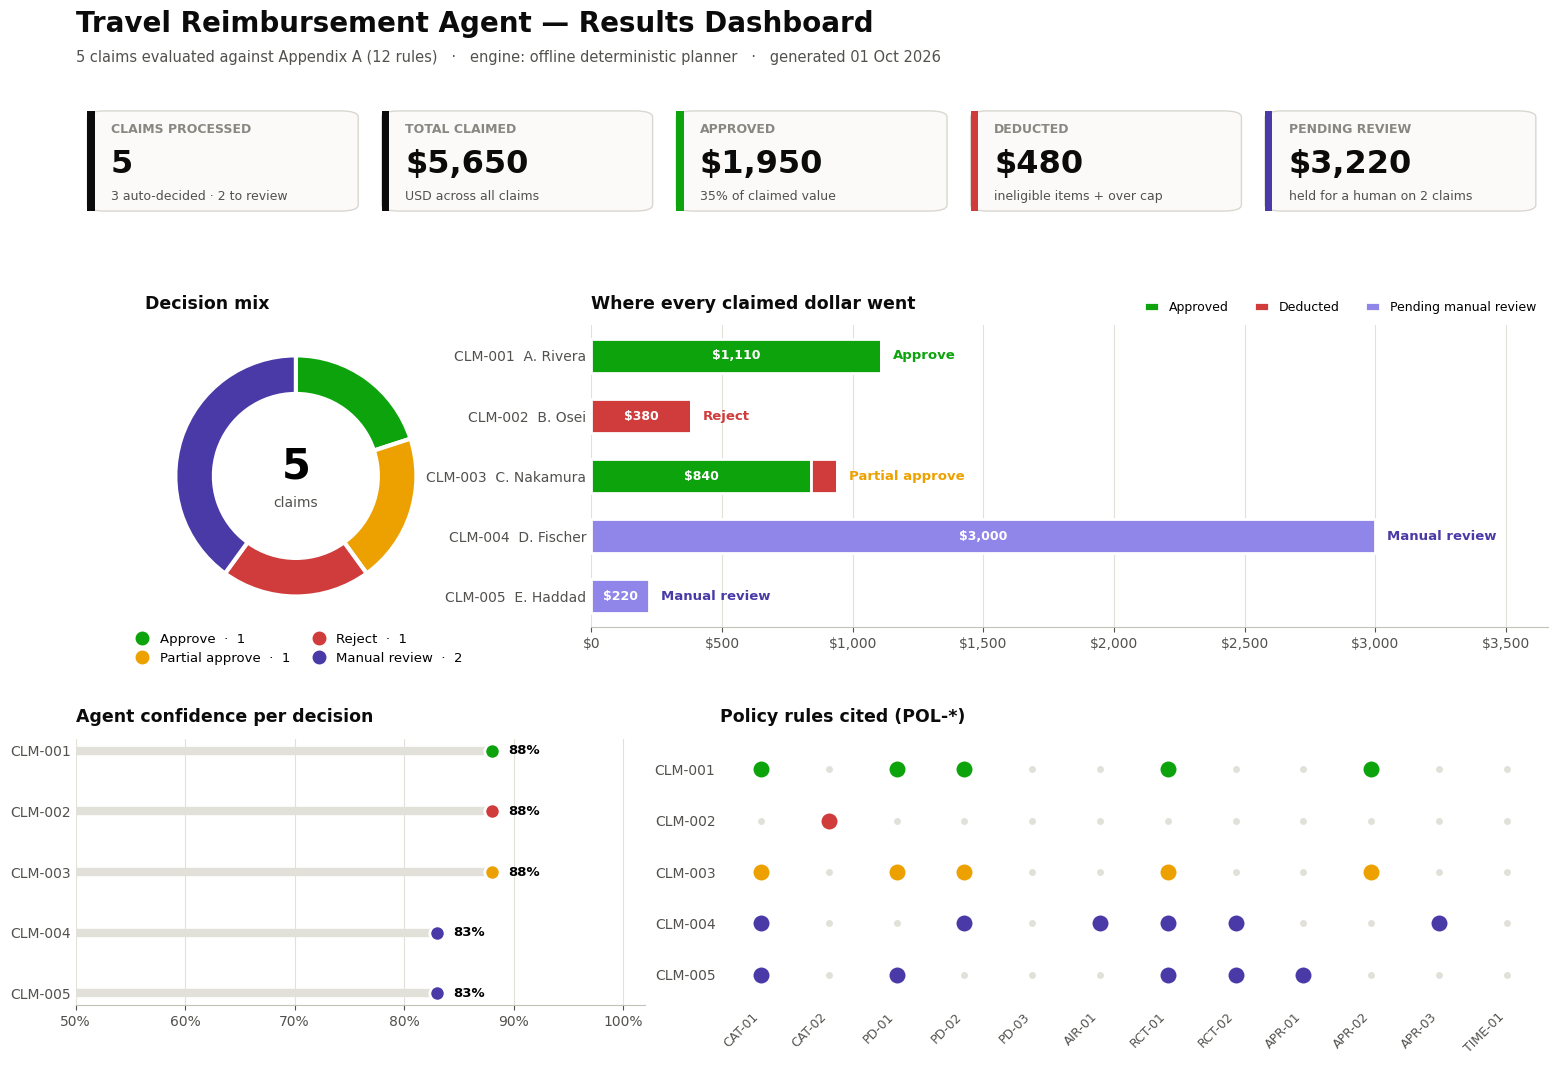

In [16]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import FuncFormatter

DECISION_ORDER = ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]
dash = results_df.copy()
dash["pending_review"] = (dash["total_claimed"] - dash["approved_amount"] - dash["deducted_amount"]).round(2)
n, n_review = len(dash), int((dash["decision"] == "MANUAL_REVIEW").sum())
tot, appr, ded, pend = (dash[c].sum() for c in ["total_claimed", "approved_amount", "deducted_amount", "pending_review"])
engine = (f"LLM agent · {LLM_MODEL} via {LLM_PROVIDER}" if (dash["mode"] == "llm").any() else "offline deterministic planner")
usd = FuncFormatter(lambda v, _: f"${v:,.0f}")

fig = plt.figure(figsize=(16, 11), facecolor=INK["surface"])
gs = fig.add_gridspec(3, 12, height_ratios=[0.45, 1.3, 1.15], hspace=0.5, wspace=1.4,
                      left=0.05, right=0.97, top=0.885, bottom=0.07)
fig.text(0.05, 0.955, "Travel Reimbursement Agent — Results Dashboard", fontsize=20, weight="bold", color=INK["primary"])
fig.text(0.05, 0.928, f"{n} claims evaluated against Appendix A (12 rules)   ·   engine: {engine}   ·   generated {date.today():%d %b %Y}",
         fontsize=10.5, color=INK["secondary"])

# ---- KPI tiles -------------------------------------------------------------------------------
axk = fig.add_subplot(gs[0, :]); axk.axis("off"); axk.set_xlim(0, 5); axk.set_ylim(0, 1)
tiles = [("CLAIMS PROCESSED", f"{n}", f"{n - n_review} auto-decided · {n_review} to review", INK["primary"]),
         ("TOTAL CLAIMED", f"${tot:,.0f}", "USD across all claims", INK["primary"]),
         ("APPROVED", f"${appr:,.0f}", f"{appr / tot:.0%} of claimed value", AMOUNT_COLORS["approved"]),
         ("DEDUCTED", f"${ded:,.0f}", "ineligible items + over cap", AMOUNT_COLORS["deducted"]),
         ("PENDING REVIEW", f"${pend:,.0f}", f"held for a human on {n_review} claims", DECISION_COLORS["MANUAL_REVIEW"])]
for i, (label, value, note, accent) in enumerate(tiles):
    x = i + 0.04
    axk.add_patch(FancyBboxPatch((x, 0.02), 0.92, 0.96, boxstyle="round,pad=0,rounding_size=0.06",
                                 fc="#fbfaf8", ec=INK["border"], lw=1, transform=axk.transData))
    axk.add_patch(FancyBboxPatch((x, 0.02), 0.025, 0.96, boxstyle="square,pad=0", fc=accent, ec="none"))
    axk.text(x + 0.08, 0.80, label, fontsize=9, color=INK["muted"], weight="bold", va="center")
    axk.text(x + 0.08, 0.47, value, fontsize=23, weight="bold", color=INK["primary"], va="center")
    axk.text(x + 0.08, 0.16, note, fontsize=9, color=INK["secondary"], va="center")

# ---- Decision mix (donut) --------------------------------------------------------------------
ax1 = fig.add_subplot(gs[1, :4])
counts = dash["decision"].value_counts().reindex(DECISION_ORDER, fill_value=0)
nz = counts[counts > 0]
ax1.pie(nz.values, colors=[DECISION_COLORS[d] for d in nz.index], startangle=90, counterclock=False,
        wedgeprops=dict(width=0.32, edgecolor="white", linewidth=3))
ax1.text(0, 0.08, f"{n}", ha="center", va="center", fontsize=30, weight="bold")
ax1.text(0, -0.22, "claims", ha="center", va="center", fontsize=10, color=INK["secondary"])
ax1.set_title("Decision mix")
ax1.legend(handles=[plt.Line2D([], [], marker="o", ls="", ms=9, color=DECISION_COLORS[d],
                               label=f"{DECISION_LABELS[d]}  ·  {counts[d]}") for d in DECISION_ORDER],
           loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=9.5, handletextpad=0.3, columnspacing=1.2)

# ---- Amount breakdown per claim (stacked horizontal bars) -----------------------------------
ax2 = fig.add_subplot(gs[1, 4:])
y = list(range(n))[::-1]
segs = [("approved_amount", "Approved", AMOUNT_COLORS["approved"]), ("deducted_amount", "Deducted", AMOUNT_COLORS["deducted"]),
        ("pending_review", "Pending manual review", AMOUNT_COLORS["pending"])]
left = [0.0] * n
xmax = dash["total_claimed"].max()
for col, label, color in segs:
    vals = dash[col].tolist()
    ax2.barh(y, vals, left=left, color=color, height=0.56, label=label, edgecolor="white", linewidth=2)
    for yi, l, v in zip(y, left, vals):
        if v >= xmax * 0.07:
            ax2.text(l + v / 2, yi, f"${v:,.0f}", ha="center", va="center", color="white", fontsize=9, weight="bold")
    left = [a + b for a, b in zip(left, vals)]
for yi, (_, r) in zip(y, dash.iterrows()):
    ax2.text(r["total_claimed"] + xmax * 0.015, yi, DECISION_LABELS[r["decision"]], va="center", fontsize=9.5,
             color=DECISION_COLORS[r["decision"]], weight="bold")
ax2.set_yticks(y)
ax2.set_yticklabels([f"{r.claim_id}  {CLAIM_STORE[r.claim_id]['employee']}" for r in dash.itertuples()], fontsize=10)
ax2.tick_params(axis="y", length=0)
ax2.xaxis.set_major_formatter(usd); ax2.set_xlim(0, xmax * 1.22)
ax2.grid(axis="x"); ax2.set_axisbelow(True); ax2.spines["left"].set_visible(False)
ax2.set_title("Where every claimed dollar went")
ax2.legend(loc="lower right", fontsize=9, ncol=3, bbox_to_anchor=(1, 1.0), handlelength=1.2)

# ---- Confidence --------------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[2, :5])
for yi, r in zip(y, dash.itertuples()):
    c = DECISION_COLORS[r.decision]
    ax3.hlines(yi, 0.5, r.confidence, color=INK["grid"], lw=6, capstyle="round")
    ax3.plot(r.confidence, yi, "o", ms=11, color=c, mec="white", mew=2)
    ax3.text(r.confidence + 0.015, yi, f"{r.confidence:.0%}", va="center", fontsize=9.5, weight="bold")
ax3.set_yticks(y); ax3.set_yticklabels(dash["claim_id"]); ax3.tick_params(axis="y", length=0)
ax3.set_xlim(0.5, 1.02); ax3.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax3.grid(axis="x"); ax3.set_axisbelow(True); ax3.spines["left"].set_visible(False)
ax3.set_title("Agent confidence per decision")

# ---- Policy rules cited (matrix) -------------------------------------------------------------
ax4 = fig.add_subplot(gs[2, 5:])
pol_ids = [p_["id"] for p_ in POLICY]
for yi, r in zip(y, dash.itertuples()):
    for xi, pid in enumerate(pol_ids):
        hit = pid in r.policy_refs
        ax4.plot(xi, yi, "o", ms=13 if hit else 5, color=DECISION_COLORS[r.decision] if hit else INK["grid"],
                 mec="white", mew=1.5 if hit else 0)
ax4.set_xticks(range(len(pol_ids))); ax4.set_xticklabels([p_.replace("POL-", "") for p_ in pol_ids], rotation=45, ha="right", fontsize=9)
ax4.set_yticks(y); ax4.set_yticklabels(dash["claim_id"]); ax4.tick_params(length=0)
ax4.set_xlim(-0.6, len(pol_ids) - 0.4); ax4.set_ylim(-0.6, n - 0.4)
for sp in ax4.spines.values():
    sp.set_visible(False)
ax4.set_title("Policy rules cited (POL-*)")

fig.savefig("UI SS_1.png", dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

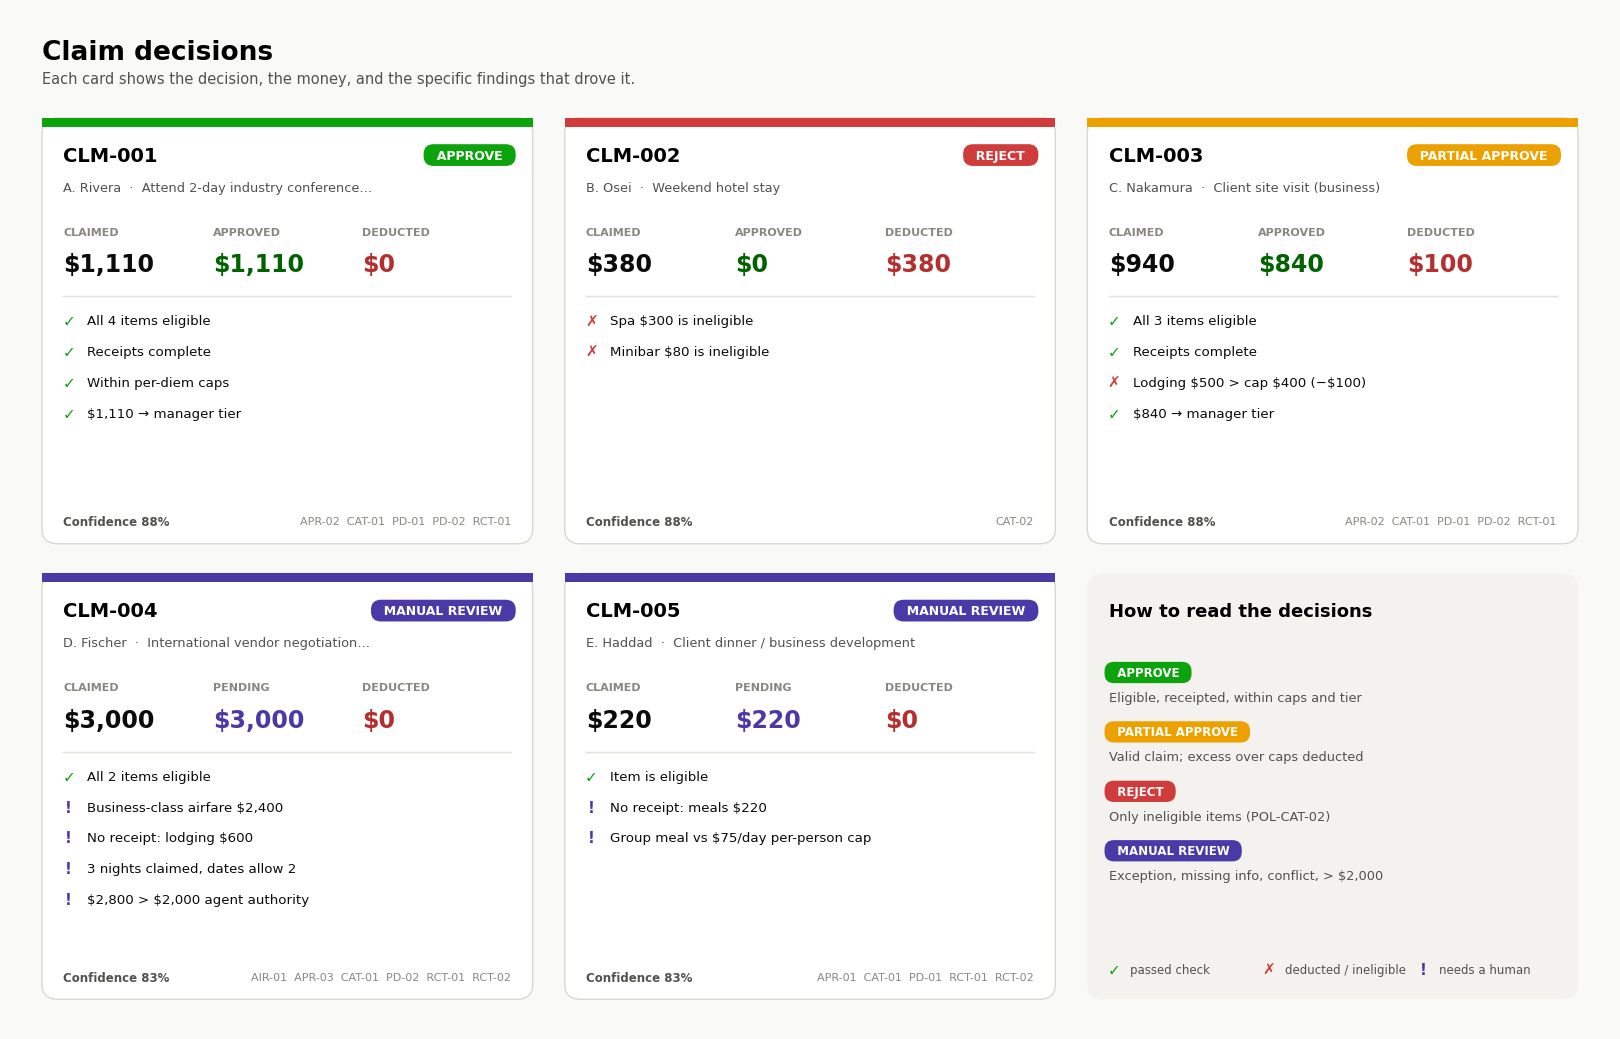

In [17]:
# Decision cards — one per claim, saved as UI SS_2.png
import textwrap
MARK = {"ok": ("✓", "#0ca30c"), "bad": ("✗", "#d03b3b"), "flag": ("!", "#4a3aa7")}

fig = plt.figure(figsize=(16, 10.2), facecolor=INK["page"])
ax = fig.add_axes([0, 0, 1, 1]); ax.axis("off"); ax.set_xlim(0, 3); ax.set_ylim(0, 2.06)
ax.text(0.06, 2.0, "Claim decisions", fontsize=19, weight="bold", va="top")
ax.text(0.06, 1.935, "Each card shows the decision, the money, and the specific findings that drove it.",
        fontsize=10.5, color=INK["secondary"], va="top")

def draw_card(ax, x, y, w, h, r):
    c, col, base = CLAIM_STORE[r["claim_id"]], DECISION_COLORS[r["decision"]], rule_baseline(r["claim_id"])
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0,rounding_size=0.03", fc="white", ec=INK["border"], lw=1))
    ax.add_patch(FancyBboxPatch((x, y + h - 0.018), w, 0.018, boxstyle="square,pad=0", fc=col, ec="none"))
    ax.text(x + 0.04, y + h - 0.075, r["claim_id"], fontsize=14, weight="bold", va="center")
    ax.text(x + 0.04, y + h - 0.14, f"{c['employee']}  ·  {textwrap.shorten(c['purpose'], 42, placeholder='…')}",
            fontsize=9.3, color=INK["secondary"], va="center")
    ax.text(x + w - 0.04, y + h - 0.075, f"  {DECISION_LABELS[r['decision']].upper()}  ", fontsize=9, weight="bold",
            color="white", ha="right", va="center",
            bbox=dict(boxstyle="round,pad=0.35,rounding_size=0.8", fc=col, ec="none"))
    for k, (label, val, vc) in enumerate([("CLAIMED", c["computed_total"], INK["primary"]),
                                           (("PENDING", c["computed_total"] - r["approved_amount"] - r["deducted_amount"], DECISION_COLORS["MANUAL_REVIEW"])
                                            if r["decision"] == "MANUAL_REVIEW" else ("APPROVED", r["approved_amount"], "#006300")),
                                           ("DEDUCTED", r["deducted_amount"], "#b42f2f")]):
        sx = x + 0.04 + k * (w - 0.08) / 3
        ax.text(sx, y + h - 0.23, label, fontsize=8, color=INK["muted"], weight="bold", va="center")
        ax.text(sx, y + h - 0.295, f"${val:,.0f}", fontsize=17, weight="bold", color=vc, va="center")
    ax.plot([x + 0.04, x + w - 0.04], [y + h - 0.36, y + h - 0.36], color=INK["grid"], lw=1)
    for k, (kind, text) in enumerate(base["findings"][:5]):
        fy = y + h - 0.41 - k * 0.062
        ax.text(x + 0.05, fy, MARK[kind][0], fontsize=11, weight="bold", color=MARK[kind][1], va="center", ha="center")
        ax.text(x + 0.085, fy, textwrap.shorten(text, 52, placeholder="…"), fontsize=9.6, va="center", color=INK["primary"])
    ax.text(x + 0.04, y + 0.045, f"Confidence {r['confidence']:.0%}", fontsize=8.5, color=INK["secondary"], weight="bold", va="center")
    ax.text(x + w - 0.04, y + 0.045, "  ".join(p_.replace("POL-", "") for p_ in r["policy_refs"]), fontsize=8,
            color=INK["muted"], va="center", ha="right")

W, H, G = 0.92, 0.86, 0.06
slots = [(0.06 + i * (W + G), 0.98 - j * (H + 0.06)) for j in range(2) for i in range(3)]
for (sx, sy), r in zip(slots, RESULTS):
    draw_card(ax, sx, sy, W, H, r)

# 6th slot: legend for how decisions are made
lx, ly = slots[5]
ax.add_patch(FancyBboxPatch((lx, ly), W, H, boxstyle="round,pad=0,rounding_size=0.03", fc="#f3f2ee", ec="none"))
ax.text(lx + 0.04, ly + H - 0.075, "How to read the decisions", fontsize=13, weight="bold", va="center")
legend_rows = [("APPROVE", "Eligible, receipted, within caps and tier"),
               ("PARTIAL_APPROVE", "Valid claim; excess over caps deducted"),
               ("REJECT", "Only ineligible items (POL-CAT-02)"),
               ("MANUAL_REVIEW", "Exception, missing info, conflict, > $2,000")]
for k, (d, txt) in enumerate(legend_rows):
    fy = ly + H - 0.2 - k * 0.12
    ax.text(lx + 0.04, fy, f"  {DECISION_LABELS[d].upper()}  ", fontsize=8.5, weight="bold", color="white", va="center",
            bbox=dict(boxstyle="round,pad=0.35,rounding_size=0.8", fc=DECISION_COLORS[d], ec="none"))
    ax.text(lx + 0.04, fy - 0.05, txt, fontsize=9.3, color=INK["secondary"], va="center")
for k, (kind, txt) in enumerate([("ok", "passed check"), ("bad", "deducted / ineligible"), ("flag", "needs a human")]):
    ax.text(lx + 0.05 + k * 0.29, ly + 0.06, MARK[kind][0], fontsize=11, weight="bold", color=MARK[kind][1], va="center", ha="center")
    ax.text(lx + 0.08 + k * 0.29, ly + 0.06, txt, fontsize=8.5, color=INK["secondary"], va="center")

fig.savefig("UI SS_2.png", dpi=130, facecolor=fig.get_facecolor())
plt.show()

### Interactive claim evaluator
Pick a sample claim, **edit the JSON** (attach the missing receipt, change the submission date, add a minibar charge…) and press **Evaluate**. Results appear in three tabs: the decision card, the audit trail and the raw JSON. *(Widgets need a live kernel — on GitHub's static viewer, see the dashboard images above.)*

In [18]:
try:
    import ipywidgets as w

    def _editable(cid):
        c = {k: v for k, v in CLAIM_STORE[cid].items() if k != "computed_total"}
        c["items"] = [{k: v for k, v in it.items() if k != "line_id"} for it in c["items"]]
        return json.dumps(c, indent=2)

    header = w.HTML(f"""
    <div style="font-family:system-ui,-apple-system,'Segoe UI',sans-serif;background:#1f1f1e;color:#fff;
                border-radius:10px 10px 0 0;padding:14px 18px">
      <div style="font-size:17px;font-weight:700">Claim evaluator</div>
      <div style="font-size:12.5px;color:#c3c2b7">Engine: {'LLM agent · ' + LLM_MODEL if LLM_CLIENT else 'offline deterministic planner'}
        · policy Appendix A · decisions validated by the guardrail</div>
    </div>""")
    pick = w.Dropdown(options=[(f"{c['claim_id']} — {c['employee']}", c["claim_id"]) for c in CLAIMS],
                      description="Sample claim", style={"description_width": "90px"}, layout=w.Layout(width="320px"))
    use_llm = w.ToggleButton(value=bool(LLM_CLIENT), description="LLM agent" if LLM_CLIENT else "LLM unavailable",
                             icon="microchip", disabled=not LLM_CLIENT, layout=w.Layout(width="150px"))
    btn = w.Button(description="Evaluate", button_style="primary", icon="play", layout=w.Layout(width="130px"))
    reset = w.Button(description="Reset", icon="undo", layout=w.Layout(width="100px"))
    box = w.Textarea(value=_editable(pick.value), layout=w.Layout(width="100%", height="290px"))
    status = w.HTML("<span style='color:#898781'>Ready.</span>")
    out_card, out_audit, out_json = w.Output(), w.Output(), w.Output()
    tabs = w.Tab(children=[out_card, out_audit, out_json])
    for k, t in enumerate(["Decision", "Audit trail", "Raw JSON"]):
        tabs.set_title(k, t)

    pick.observe(lambda ch: setattr(box, "value", _editable(ch["new"])), names="value")
    reset.on_click(lambda _: setattr(box, "value", _editable(pick.value)))

    def _on_click(_):
        for o in (out_card, out_audit, out_json):
            o.clear_output()
        status.value = "<span style='color:#2a78d6'>Evaluating…</span>"
        try:
            claim = json.loads(box.value)
            res, run = evaluate_claim(claim, client=None if use_llm.value else False)
            RUNS[res["claim_id"]] = run
            with out_card:
                display(HTML(result_card(res)))
            with out_audit:
                display(show_audit(res["claim_id"]))
            with out_json:
                print(json.dumps(res, indent=2))
            col = DECISION_COLORS[res["decision"]]
            status.value = (f"<b style='color:{col}'>{DECISION_LABELS[res['decision']]}</b> "
                            f"<span style='color:#52514e'>· {res['claim_id']} · {run.mode} mode · {len(run.tools_used)} tools</span>")
            tabs.selected_index = 0
        except Exception as e:
            status.value = f"<b style='color:#d03b3b'>Invalid claim:</b> {type(e).__name__}: {e}"

    btn.on_click(_on_click)
    controls = w.HBox([pick, use_llm, btn, reset], layout=w.Layout(gap="8px", align_items="center", padding="10px 0"))
    body = w.VBox([controls, box, status, tabs],
                  layout=w.Layout(border="1px solid #e1e0d9", padding="4px 16px 16px", border_radius="0 0 10px 10px"))
    display(w.VBox([header, body]))
except ImportError:
    print("ipywidgets not installed — run `pip install ipywidgets` to use the interactive form.")

## Design Notes & Reasoning

### Approach
* **Hybrid agent: LLM for judgement, code for money.** The LLM decides *which* checks to run, reads their results, spots ambiguity a rule did not foresee and writes the reviewer-facing explanation. Caps, deductions, totals and tiers are computed by Python tools. This keeps the decisions reproducible and auditable while still showing real tool-calling behaviour.
* **Context grounding.** Policy rules are data with stable ids. `retrieve_policy` (TF-IDF) returns rule text to the LLM; the validator only lets real `POL-*` ids into the output.
* **Workflow control in code, not only in the prompt.** The agent cannot submit a decision before the four core checks have run; the claim id is pinned so the model cannot evaluate a different claim; a step limit prevents loops.
* **Guardrail that only moves toward safety.** The rule engine is the floor. An LLM may escalate to `MANUAL_REVIEW` but may never approve something the rules stop. When LLM and rules disagree on an automatic decision, that disagreement is itself treated as conflicting information → `MANUAL_REVIEW`.

### Why each claim landed where it did
| Claim | Decision | Reasoning |
|---|---|---|
| CLM-001 | APPROVE $1,110 | All 4 items eligible with receipts; lodging $180/night < $200; meals $60/day < $75; $1,110 is manager tier (POL-APR-02), approvable when compliant. |
| CLM-002 | REJECT, $380 deducted | Spa and minibar are both POL-CAT-02 ineligible; nothing reimbursable. |
| CLM-003 | PARTIAL_APPROVE $840 / $100 deducted | Lodging 2 nights × $250 = $500 vs cap $400 → $100 excess (POL-PD-02). Meals $70/day are within $75. |
| CLM-004 | MANUAL_REVIEW | Four independent triggers: business-class airfare is a policy exception (POL-AIR-01, not auto-deducted because pre-approval may exist); hotel receipt missing (POL-RCT-02); the total is above the $2,000 agent authority even after capping lodging to the 2 nights the dates support ($2,800) (POL-APR-03); and "3 nights" conflicts with a 16→18 June trip that supports only 2 nights. |
| CLM-005 | MANUAL_REVIEW | $220 meal with no receipt (POL-RCT-01/02). Also ambiguous: a client dinner for 4 against a per-person $75 daily cap — the reviewer must decide whether it's client entertainment with pre-approval or should be capped (provisional deduction $145 is shown). |

### Why route to Manual Review instead of deciding
The policy explicitly prefers it, and the cost of errors is asymmetric: wrongly paying a non-compliant claim is a financial-control failure, while a manual review costs a few minutes of a reviewer's time. So anything that depends on information the agent cannot see — a pre-approval, a missing receipt, which of two conflicting facts is true, an amount above the agent's authority — goes to a human with the specific reason and the documents to request (`missing_docs`).

### Assumptions
* "Expense date" for POL-TIME-01 is the **trip start** (conservative: earliest possible expense).
* Units for caps come from the line description ("2 nights", "3 days"); if missing, from trip dates (days inclusive, nights = days − 1). If the description claims more units than the dates allow, that is a conflict → manual review.
* Under `MANUAL_REVIEW`, `approved_amount = 0` (nothing is paid automatically). `deducted_amount` counts only POL-CAT-02 items, which are never reimbursable; cap-based deductions are shown as provisional in the explanation.
* A claim mixing ineligible and valid items is `PARTIAL_APPROVE` (ineligible lines deducted in full).
* An airfare line that doesn't state its class is treated as ambiguous (manual review), not assumed economy.
* Confidence = agreement between LLM and rules (0.95 agree / 0.65 disagree / 0.88 rules-only) minus 0.05 per data conflict or ambiguity, capped by the LLM's own confidence.

### Trade-offs
* **TF-IDF instead of embeddings + vector DB** — 12 rules don't justify the extra dependency; swap in embeddings when the policy grows to hundreds of clauses.
* **Rules duplicated in code and in the LLM's reasoning** — deliberate redundancy; the LLM adds flexibility, the code adds guarantees.
* **Single agent, no multi-agent framework** — CrewAI/LangGraph would add moving parts without improving decisions here. The raw OpenAI-compatible tool loop is ~60 lines and works with Groq, Ollama or OpenAI unchanged.
* **Offline fallback** — guarantees the notebook always runs and the demo never breaks on a rate limit, at the cost of a templated (less natural) explanation.

### Known gaps & what I'd improve next
1. Receipt OCR / extraction (e.g. a vision model) to check receipt amount, date and itemisation against the line — today `receipt_attached` is trusted.
2. Per-day expense dates per line (current data has only trip ranges), so meals and ground caps can be checked day by day.
3. Pre-approval lookup tool (for business class / client entertainment) so some exceptions can be cleared automatically.
4. Currency conversion and per-city per-diem tables.
5. Expose the tools through an **MCP server** so the same checks can be reused by other agents; persist audit trails to a database.
6. A larger labelled evaluation set (50–100 synthetic claims) and tracking LLM-vs-rules agreement rate over time.

## Assumptions & Limitations (summary)
* Mock policy and claims only; no real employee data. Currency is USD.
* Receipt presence is taken from the claim data — receipts are not actually inspected.
* Duplicate detection only compares claims loaded in this session.
* LLM output varies slightly between runs/providers; decisions and amounts are stabilised by the guardrail, the explanation wording may change.
* Free-tier rate limits may slow the run; on failure the claim is evaluated by the deterministic fallback and marked `mode = fallback`.

## 12 · Final structured results
One object per claim with exactly: `claim_id, decision, approved_amount, deducted_amount, missing_docs, policy_refs, confidence, explanation, tools_used`.

In [19]:
final_results = [{k: r[k] for k in OUTPUT_FIELDS} for r in RESULTS]
assert len(final_results) == 5 and all(list(r) == OUTPUT_FIELDS for r in final_results)
with open("results.json", "w") as f:
    json.dump(final_results, f, indent=2)
print(json.dumps(final_results, indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01"
    ],
    "confidence": 0.88,
    "explanation": "All 4 items are eligible, receipts are attached and every amount is within per-diem limits. Reimbursable total $1,110.00 falls in the manager tier, so the claim is approvable.",
    "tools_used": [
      "retrieve_policy",
      "check_category_eligibility",
      "check_per_diem_limits",
      "check_receipts",
      "check_airfare_class",
      "check_submission_window",
      "detect_duplicates",
      "check_approval_threshold",
      "validate_decision"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confidence": 0.88,
    